# Figure generation code for Postema *et al* 2027
This Jupyter notebook generates the figures included in "Angular momenta and pressure relationships in rotating terrestrial planets" by A.N. Postema ([adriana.n.postema@unb.ca](mailto:adriana.n.postema@unb.ca)) , S.J. Lock ([s.lock@bristol.ac.uk](mailto:s.lock@bristol.ac.uk)), and S.T. Stewart ([sstewa56@asu.edu](mailto:sstewa56@asu.edu))

There is a companion Mathematica notebook to this Jupyter notebook. Running this Jupyter notebook first is necessary to produce the files that the Mathematica notebook reads in.

The accompanying data for these figures is located on Zenodo at DOI: 10.5281/zenodo.21794482. The contents of that data repository should be extracted each to their own folder and placed in this working directory. I.e., there should be four folders located at "./output/", "./planet_profiles/", "./HERC_profiles/", and "./HERC_yaml/".

### Initializing packages and basic functions

In [1]:
# Record the verions information for these calculation for posterity
import platform
print('python version: ',platform.python_version())
del platform
import matplotlib
print('matplotlib version: ', matplotlib.__version__)
del matplotlib
import numpy
print('numpy version: ', numpy.__version__)
del numpy
import scipy
print('scipy version: ', scipy.__version__)
del scipy

import sys

import woma
from woma.misc import glob_vars as gv
from woma.eos import sesame
#from woma.eos.T_rho import T_rho

R_earth = gv.R_earth #6.371e6   # m
M_earth = gv.M_earth #5.9724e24  # kg 
G = gv.G #6.67408e-11  # m^3 kg^-1 s^-2
LEM=3.5E34 #AMof Earth-Moon system in mks

# First we import python libraries
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from scipy import interpolate
from mpl_toolkits.axes_grid1 import make_axes_locatable
#import colormaps as local_cmaps
import os
from copy import deepcopy
from pathlib import Path
import pkgutil
import h5py
import yaml
print(yaml.__version__)
from HERCULES_structures import *
from isentrope_planet import *
from hercrun import *

#%run eostable.py

%config InlineBackend.figure_format = 'retina'

plt.rcParams["figure.figsize"] = (20,10) # default figure size in inches

#eospath = os.path.expanduser('~') + '/Work/'
#eospath = '../'

mant_mat_id = 403 #USER INPUT
core_mat_id = 402 #USER INPUT

python version:  3.14.2
matplotlib version:  3.10.8
numpy version:  2.3.5
scipy version:  1.16.3
6.0.3


In [2]:
def gradient2(x,y):
    #define the difference between all the points
    dx=np.diff(x)
    #define the output array
    dydx=np.empty(np.size(y))
    #use centered difference for the middle points
    dydx[1:-1]=(y[2:]*(dx[0:-1]**2.0)-y[0:-2]*(dx[1:]**2.0)-y[1:-1]*((dx[0:-1]**2.0)-
                        (dx[1:]**2.0)))/(dx[0:-1]*dx[1:]*(dx[1:]+dx[0:-1]))
    #use forward diff for first point
    dydx[0]=(y[2]*(dx[0]**2)-y[1]*((dx[1]+dx[0])**2)-y[0]*((dx[0]**2)-((dx[1]+dx[0])**2)))/(dx[0]*(dx[0]+dx[1])*-dx[1])
    #use backwards difference for the last point
    dydx[-1]=(y[-3]*(dx[-1]**2)-y[-2]*((dx[-1]+dx[-2])**2)-y[-1]*((dx[-1]**2)-((dx[-1]+dx[-2])**2)))/(dx[-1]*(dx[-1]+dx[-2])*dx[-2])
    return dydx

### Loading all HERCULES runs (this will take awhile)

In [3]:
filelist = np.array([])
masslist = np.array([])
planetdict = {}
hercdict = {}
for filename in os.listdir("./planet_profiles/"):
    if filename.endswith(".txt") and not filename.endswith(".used_params.txt"):
        if filename.startswith("MO") or filename.startswith("DMO") or filename.startswith("HMO") or filename.startswith("PMO"):
            pass
        #print(filename)
        else:
            path = './planet_profiles/'+filename
            basename=np.char.split(filename,'N').item()[0] #assuming the same naming format as in MakePlanets
            filelist = np.append(filelist,basename)
            planet = planet_profile(file=path)
            planetdict[basename] = planet
            hercrun = HERC_run(planet=planet)
            hercdict[basename] = hercrun
            hercrun.load_data(path='./output/')
            masslist=np.append(masslist,hercrun.M)

masssort = masslist[np.argsort(masslist)]
keylist=filelist[np.argsort(masslist)]

M.0017PyroSCmantleSMwarmN29_fulltension.txt
M.0017PyroSCmantleSMwarm_L0.000100005_N150_Nm400_k6_f021_p0.1_l1_0_1.5_final
PARAM FORMAT 1
ERROR: READ WITH FORMAT 1 UNSUCCESSFUL
PARAM FORMAT 0
PARAM READ SUCCESSFUL WITH FORMAT 0
OUTPUT FORMAT 0
OUTPUT READ SUCCESSFUL WITH FORMAT 0
Loaded HERCULES output  M.0017PyroSCmantleSMwarm_L0.000100005_N150_Nm400_k6_f021_p0.1_l1_0_1.5_final
748278.3222279854
M.0017PyroSCmantleSMwarm_L0.000100005_N200_Nm400_k6_f021_p0.1_l1_0_1.5_final
PARAM FORMAT 1
PARAM READ SUCCESSFUL WITH FORMAT 1
OUTPUT FORMAT 1
OUTPUT READ SUCCESSFUL WITH FORMAT 1
Loaded HERCULES output  M.0017PyroSCmantleSMwarm_L0.000100005_N200_Nm400_k6_f021_p0.1_l1_0_1.5_final
748278.2530212103
M.0017PyroSCmantleSMwarm_L0.000102862_N150_Nm400_k6_f021_p0.1_l1_0_1.5_final
PARAM FORMAT 1
ERROR: READ WITH FORMAT 1 UNSUCCESSFUL
PARAM FORMAT 0
PARAM READ SUCCESSFUL WITH FORMAT 0
OUTPUT FORMAT 0
OUTPUT READ SUCCESSFUL WITH FORMAT 0
Loaded HERCULES output  M.0017PyroSCmantleSMwarm_L0.000102862_N150_

## Figure 1

Planet mass: 1.8989924820842543
COROL (in LEM) 11.123254544900673 -1
Maximum L seen: 11.228208718686973


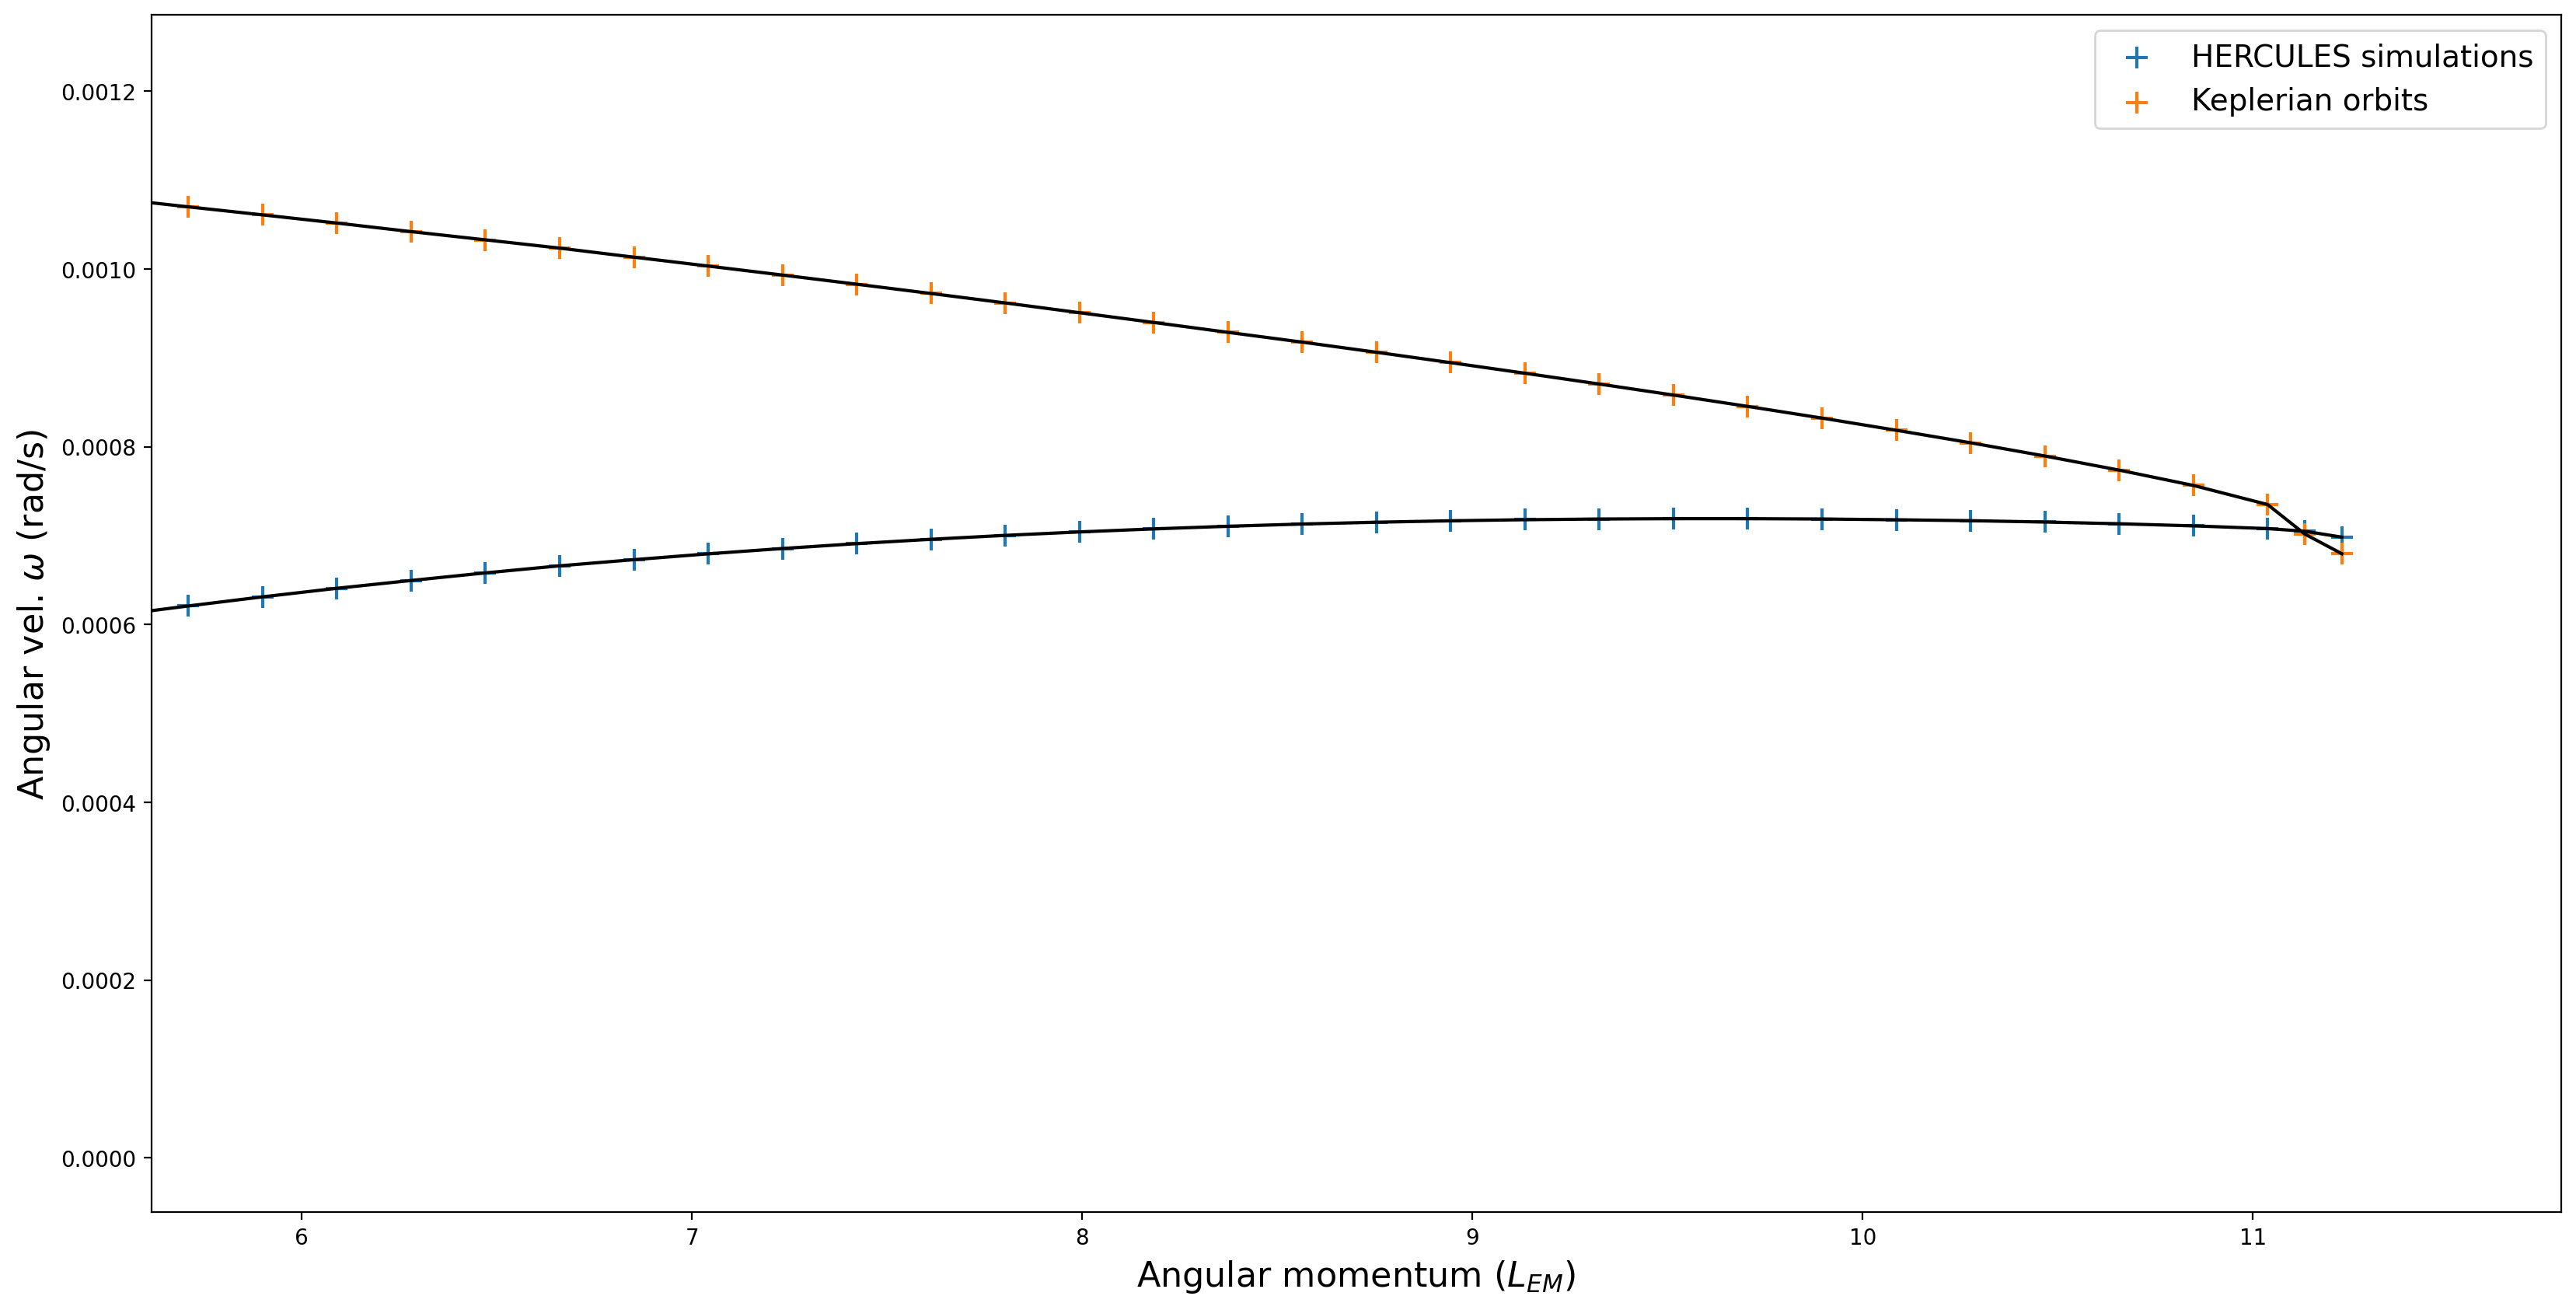

In [4]:
from scipy.optimize import brentq

## REPLACE KEYLIST[i] WITH ANY VALUE 0-24 TO SEE AN HERCULES COROL-FINDING METHOD FOR A GIVEN MASS
key=hercdict[keylist[24]]
print("Planet mass:",key.M/M_earth)
keparr=np.array([])

for i in range(np.size(key.Ltot)):
    #print(key.keys)
    p=key.planetdict[key.keys[i]]
    radius=np.empty(p.Nlayer)
    for k in np.arange(p.Nlayer):
        radius[k]=p.layers[k].a
    dVdr=gradient2(radius, p.Ulayers-(((radius*p.omega_rot)**2)/2.0))
    temp=np.sqrt(-1.0*dVdr/radius)
    keparr=np.append(keparr,temp[0])

hercinterp=interpolate.interp1d(key.Ltot/LEM,key.w)
kepinterp=interpolate.interp1d(key.Ltot/LEM,keparr)
def diffinterp(x): return kepinterp(x)-hercinterp(x)

found=False
jj=-1
while not found:
    try:
        intersect=brentq(diffinterp,0,key.Ltot[jj]/LEM)
        found=True
    except:
        jj-=1
        found=False
        if (jj*-1)>np.size(key.Ltot):
            found=True
            intersect=key.Ltot[-1]/LEM
            print('NOPE')
print(r"COROL (in LEM)",intersect,jj)
print('Maximum L seen:',key.Ltot[-1]/LEM)

#plt.scatter(intersect,hercinterp(intersect))
plt.plot(key.Ltot/LEM,key.w,c='k')
plt.scatter(key.Ltot/LEM,key.w,marker='+',s=100,label='HERCULES simulations')
#plt.scatter(key.Ltot/LEM,np.sqrt(G*key.M/key.r1**3))
plt.plot(key.Ltot/LEM,keparr,c='k')
plt.scatter(key.Ltot/LEM,keparr,marker='+',s=100,label='Keplerian orbits')

#plt.plot(key.Ltot/LEM,keparr-key.w)
#plt.plot(key.Ltot/LEM,np.zeros(np.size(key.Ltot)))
plt.xlim(0.5*np.amax(key.Ltot/LEM),None)
plt.ylim(None,None)
plt.ylabel('Angular vel. $\omega$ (rad/s)',fontsize=16)
plt.xlabel('Angular momentum ($L_{EM}$)',fontsize=16)
plt.legend(fontsize=14)
imname='corol_test'+'.pdf'
plt.savefig(imname,bbox_inches='tight')
plt.show()

Repeating the CoRoL-finding process for all of the masses included in this study produces the following points:

In [5]:
Mcorols=np.array([0.001667078114325899,0.0033328373518183648,0.004999976776505257,0.010007283755274262,0.01668026595673431,
                 0.03332227848101266,0.050025178320273256,0.05499963281093027,0.08336844585091421,0.10006790670417252,
                 0.1517723913334673,0.16672166683410355,0.2166383263009845,0.25007144364074746,0.303408095572969,
                 0.43344730426629163,0.45499484461857875,0.5004180781595339,0.55041936909785,0.650453482687027,
                 0.7061969878105955,0.9101278849373786,1.298940668742884,1.4994135841537741,1.8989924820842543])

Lcorols=np.array([0.00012447033904915784,0.00039502183308535863,0.0007444225241437411,0.00240120174873789,0.005551311900630305,
                0.017157726045287394,0.03381365968505444,0.03836327694725919,0.0773205762982478,0.1050581915602321,
                0.20073137289397133,0.23918591990153856,0.3625849510797259,0.459228117865086,0.6238917541718889,
                1.1041937495542355,1.1886257061605843,1.3826165121697431,1.613592485882808,2.0929219937028063,
                2.3947487129564395,3.557411804014438,6.19806378501693,7.746299856523397,11.123254544900673])


In [6]:
### Writing to a file for Mathematica to use
with open('chosen_maxL.csv','w') as wfile:
    for i in range(np.size(Mcorols)):
        wfile.write('%.9e'%(Mcorols[i])+','+'%.9e'%(Lcorols[i])+'\n')

In [7]:
CoRoLinterp=interpolate.interp1d(Mcorols,Lcorols)

In [8]:
### Writing to a file for Mathematica to use
for keyname in keylist:
    outname=keyname+'_out.csv'
    key=hercdict[keyname]
    with open(outname,'w') as wfile:
        for i in range(np.size(key.Ltot)):
            if key.Ltot[i]/LEM<=CoRoLinterp(key.M/M_earth):
                wfile.write('%.9e'%(key.Ltot[i]/LEM)+','+'%.9e'%(key.PCMB[i]/1.e9)+'\n')

## Figure 2

In [9]:
%run eostable.py
eospath = '../'
def loadEOS(eos='Iron-ANEOS-SLVTv0.2G1'):
# READ IN NEW ANEOS MODEL and fill the extEOStable class object
# source in eostable.py
#------------------------------------------------------------------

    if eos == 'Fe85Si15-ANEOS-SLVTv0.2G1':
        eosdir = eospath + 'aneos-Fe85Si15-2020/'
        # ====>>>>>> YOU NEED TO MAKE SURE THESE VALUES MATCH ANEOS.INPUT  <<<<=====
        MODELNAME = 'Fe85Si15-ANEOS-SLVTv0.2G1'
        # Header information must all be compatible with float format
        MATID = 1.0        # MATID number
        DATE = 191105.     # Date as a single 6-digit number YYMMDD
        VERSION = 0.2      # ANEOS Parameters Version number
        FMN = 24.20        # Formula weight in atomic numbers for Fe85Si15
        FMW = 51.68        # Formula molecular weight (g/cm3) for Fe85Si15
        # The following define the default initial state for material in the 201 table
        R0REF   = 7.51     # g/cm3 *** R0REF is inserted into the density array; using gamma-iron for rho0
        K0REF   = 1.51E12  # dynes/cm2; using gamma-iron for rho0
        T0REF   = 298.     # K -- *** T0REF is inserted into the temperature array
        P0REF   = 1.E6     # dynes/cm2 -- this defines the principal Hugoniot calculated below
        #-------------------------------------------------------------

    elif eos == 'Forsterite-ANEOS-SLVTv1.0G1':
        eosdir = eospath + 'aneos-forsterite-2019/'
        MODELNAME = 'Forsterite-ANEOS-SLVTv1.0G1'
        # Header information must all be compatible with float format
        MATID = 1.0        # MATID number
        DATE = 190802.     # Date as a single 6-digit number YYMMDD
        VERSION = 0.1      # ANEOS Parameters Version number
        FMN = 70.          # Formula weight in atomic numbers for Mg2SiO4
        FMW = 140.691      # Formula molecular weight (g/cm3) for Mg2SiO4
        # The following define the default initial state for material in the 201 table
        R0REF   = 3.22     # g/cm3 *** R0REF is inserted into the density array
        K0REF   = 1.1E12   # dynes/cm2
        T0REF   = 298.     # K -- *** T0REF is inserted into the temperature array
        P0REF   = 1.E6     # dynes/cm2 -- this defines the principal Hugoniot calculated below
        
    elif eos == 'Pyrolite-ANEOS-SLVTv0.2G1':
        eosdir = eospath + '/aneos-pyrolite-2022//'
        MODELNAME = 'Pyrolite-ANEOS-SLVTv0.2G1'
        # Header information must all be compatible with float format
        MATID = 1.0        # MATID number
        DATE = 210627.     # Date as a single 6-digit number YYMMDD
        VERSION = 0.1      # ANEOS Parameters Version number
        FMN = 153.          # Formula weight in atomic numbers for Mg2SiO4
        FMW = 3234.61      # Formula molecular weight (g/cm3) for Mg2SiO4
        # The following define the default initial state for material in the 201 table
        R0REF   = 3.35     # g/cm3 *** R0REF is inserted into the density array
        K0REF   = 0.95E12  # dynes/cm2
        T0REF   = 298.     # K -- *** T0REF is inserted into the temperature array
        P0REF   = 1.E6     # dynes/cm2 -- this defines the principal Hugoniot calculated below
    
    
    
    NewEOS  = extEOStable() # FIRST make new empty EOS object
    NewEOS.loadextsesame(eosdir+'NEW-SESAME-EXT.TXT') # LOAD THE EXTENDED 301 SESAME FILE GENERATED BY STSM VERSION OF ANEOS
    NewEOS.loadstdsesame(eosdir+'NEW-SESAME-STD.TXT') # LOAD THE STANDARD 301 SESAME FILE GENERATED BY STSM VERSION OF ANEOS
    NewEOS.MODELNAME = MODELNAME # string set above in user input
    NewEOS.MDQ = np.zeros((NewEOS.NT,NewEOS.ND)) # makes the empty MDQ array
    #print(NewEOS.units) # these are the default units for SESAME rho-T tables
    #'Units: g/cm3, K, GPa, MJ/kg, MJ/kg, MJ/K/kg, cm/s, MJ/K/kg, KPA flag. 2D arrays are (NT,ND).'

    # Add the header info to the table. This could be done during the loading. 
    # if made from this notebook, these values are set in the user-input above.
    # ** MAKE SURE THEY MATCH ANEOS.INPUT **
    NewEOS.MATID   = MATID
    NewEOS.DATE    = DATE
    NewEOS.VERSION = VERSION
    NewEOS.FMN     = FMN
    NewEOS.FMW     = FMW
    NewEOS.R0REF   = R0REF
    NewEOS.K0REF   = K0REF
    NewEOS.T0REF   = T0REF
    NewEOS.P0REF   = P0REF
    #
    # Load the information from ANEOS.INPUT and ANEOS.OUTPUT
    NewEOS.loadaneos(aneosinfname=eosdir+'ANEOS.INPUT',aneosoutfname=eosdir+'ANEOS.OUTPUT',silent=True)
    #
    NewEOS.calchugoniot(r0=NewEOS.R0REF,t0=NewEOS.T0REF,silent=True)
    #
    # calculate the 1-bar profile; loop over temp
    NewEOS.onebar.T = np.zeros(NewEOS.NT)
    NewEOS.onebar.S = np.zeros(NewEOS.NT)
    NewEOS.onebar.rho = np.zeros(NewEOS.NT)
    it0 = np.where(NewEOS.T >= NewEOS.T0REF)[0]
    id0 = np.arange(NewEOS.ND)#np.where(NewEOS.rho >= 0.8*NewEOS.R0REF)[0]
    for iit in range(0,NewEOS.NT):
        NewEOS.onebar.T[iit] = NewEOS.T[iit]
        NewEOS.onebar.S[iit] = np.interp(1.E-4,NewEOS.P[iit,id0],NewEOS.S[iit,id0])
        NewEOS.onebar.rho[iit] = np.interp(1.E-4,NewEOS.P[iit,id0],NewEOS.rho[id0])

    return NewEOS

AlloyEOS = loadEOS(eos='Fe85Si15-ANEOS-SLVTv0.2G1')
ForsteriteEOS = loadEOS(eos='Forsterite-ANEOS-SLVTv1.0G1')
PyroliteEOS = loadEOS(eos='Pyrolite-ANEOS-SLVTv0.2G1')

In [10]:
Gcgs = 6.67E-8 # Gravitational constant  cm3/g/s2
Mearthcgs = 5.972E27 # Earth's mass g
Rearthcgs = 6371.E5  # Earth's radius cm
Rcmbcgs = 348000000. # CMB radius in cm (from PREM)

datadir='./'
peridotitefile = open(datadir+"Fiquet-2010-Science-Peridotite-Melting-Fig3-solidus.txt","r")  
peridotitesolidusdatarr = pd.read_csv(peridotitefile,skiprows=1)
peridotitefile.close() 

In [11]:
def potentialT(refP,refT,EOS):
    refP_T = np.zeros(EOS.NT)
    refP_S = np.zeros(EOS.NT)
    refP_rho = np.zeros(EOS.NT)
    id0 = np.arange(EOS.ND)
    for iit in range(0,EOS.NT):
        refP_T[iit] = EOS.T[iit]
        refP_S[iit] = np.interp(refP/1.E10,EOS.P[iit,id0],EOS.S[iit,id0])
        refP_rho[iit] = np.interp(refP/1.E10,EOS.P[iit,id0],EOS.rho[id0])
    Sval = np.interp(refT,refP_T,refP_S)*1e3 # kJ/kg/K
    return Sval

In [12]:
#filename='./planet_profiles/M1.5PyroSCmeltSMwarmN128.txt'
#planet=planet_profile(file=filename)
#core = isentrope_class(entropy=1.82435084*1.e6)
#mantle = isentrope_class(entropy=2.82010204*1.e6)

def plot_PT_profile(planet,core,mantle,particleplanet=None,path=False,coreEOS='alloy',mantleEOS='pyrolite',showPREM=False):

    if coreEOS == 'iron':
        cEOS = IronEOS
    elif coreEOS == 'alloy':
        cEOS = AlloyEOS
    else:
        print('Unknown core EOS')
        return
    
    if mantleEOS == 'forsterite':
        mEOS = ForsteriteEOS
    elif mantleEOS == 'pyrolite':
        mEOS = PyroliteEOS
    else:
        print('Unknown mantle EOS')
        return
    
    sfont=15 # I like to set the size of my fonts


    # loop across all densities and extract the values for the requested isentrope
    for i in range(0,mEOS.ND):
        ind = np.where((mEOS.S[:,i] > 0))[0]
        interpfunction = interpolate.interp1d(mEOS.S[ind,i],mEOS.P[ind,i]) # MJ/K/kg, GPa
        mantle.pressure = np.append(mantle.pressure,interpfunction(mantle.entropy/1.E3)) # GPa
        interpfunction = interpolate.interp1d(mEOS.S[ind,i],mEOS.T[ind]) # MJ/K/kg, GPa
        mantle.temperature = np.append(mantle.temperature,interpfunction(mantle.entropy/1.E3)) # GPa
        interpfunction = interpolate.interp1d(mEOS.S[ind,i],mEOS.U[ind,i]) # MJ/kg/K, MJ/kg
        mantle.energy = np.append(mantle.energy,interpfunction(mantle.entropy/1.E3)) # MJ/kg
    mantle.density = mEOS.rho # g/cm

    for i in range(0,cEOS.ND):
        ind = np.where((cEOS.S[:,i] > 0))[0]
        interpfunction = interpolate.interp1d(cEOS.S[ind,i],cEOS.P[ind,i]) # MJ/K/kg, GPa
        core.pressure = np.append(core.pressure,interpfunction(core.entropy/1.E3)) # GPa
        interpfunction = interpolate.interp1d(cEOS.S[ind,i],cEOS.T[ind]) # MJ/K/kg, GPa
        core.temperature = np.append(core.temperature,interpfunction(core.entropy/1.E3)) # GPa
        interpfunction = interpolate.interp1d(cEOS.S[ind,i],cEOS.U[ind,i]) # MJ/kg/K, MJ/kg
        core.energy = np.append(core.energy,interpfunction(core.entropy/1.E3)) # MJ/kg
    core.density = cEOS.rho # g/cm3

    # we just need 1 plot
    fig = plt.figure(figsize=(12,7))
    print(mantle.pressure)
    plt.plot(mantle.pressure,mantle.temperature,'-',color='green',label='Mantle isentrope',markersize=10)
    plt.plot(core.pressure,core.temperature,'-',color='orange',label='Core isentrope',markersize=10)
    
    plt.plot(mEOS.mc.Pl,mEOS.mc.T,'-',color='black',label='Mantle melt curve',markersize=10)
    plt.plot(cEOS.mc.Pl,cEOS.mc.T,'--',color='black',label='Core melt curve',markersize=10)
    plt.plot(peridotitesolidusdatarr.iloc[:,0].values,peridotitesolidusdatarr.iloc[:,1].values,linestyle=':',color='darkgreen',label='Peridotite Solidus\n(Fiquet et al. 2010)')
    plt.plot(planet.pressure[1:]/1.e10,planet.temperature[1:],'-',color='blue',label='Planet model profile')


    #plt.ylim(0.,max(PREM.temperature))
    plt.ylim(1600.,6000)
    #plt.ylim(4500.,5500)
    plt.xlim(0,max(planet.pressure[1:]/1.e10))
    #plt.xlim(200,300)
    plt.xlabel('Pressure (GPa)',size=sfont+6)
    plt.ylabel('Temperature (K)',size=sfont+6)
    #plt.title('Model 1-D P-T Profile',size=sfont)
    plt.tick_params(labelsize=sfont)
    plt.legend(fontsize=sfont)
    imname='thermo_profile'+'.pdf'
    plt.savefig(imname)
    plt.show()

[2.14236654e-22 2.40027912e-22 2.69579344e-22 ... 1.14009794e+06
 1.14389821e+06 1.14770570e+06]


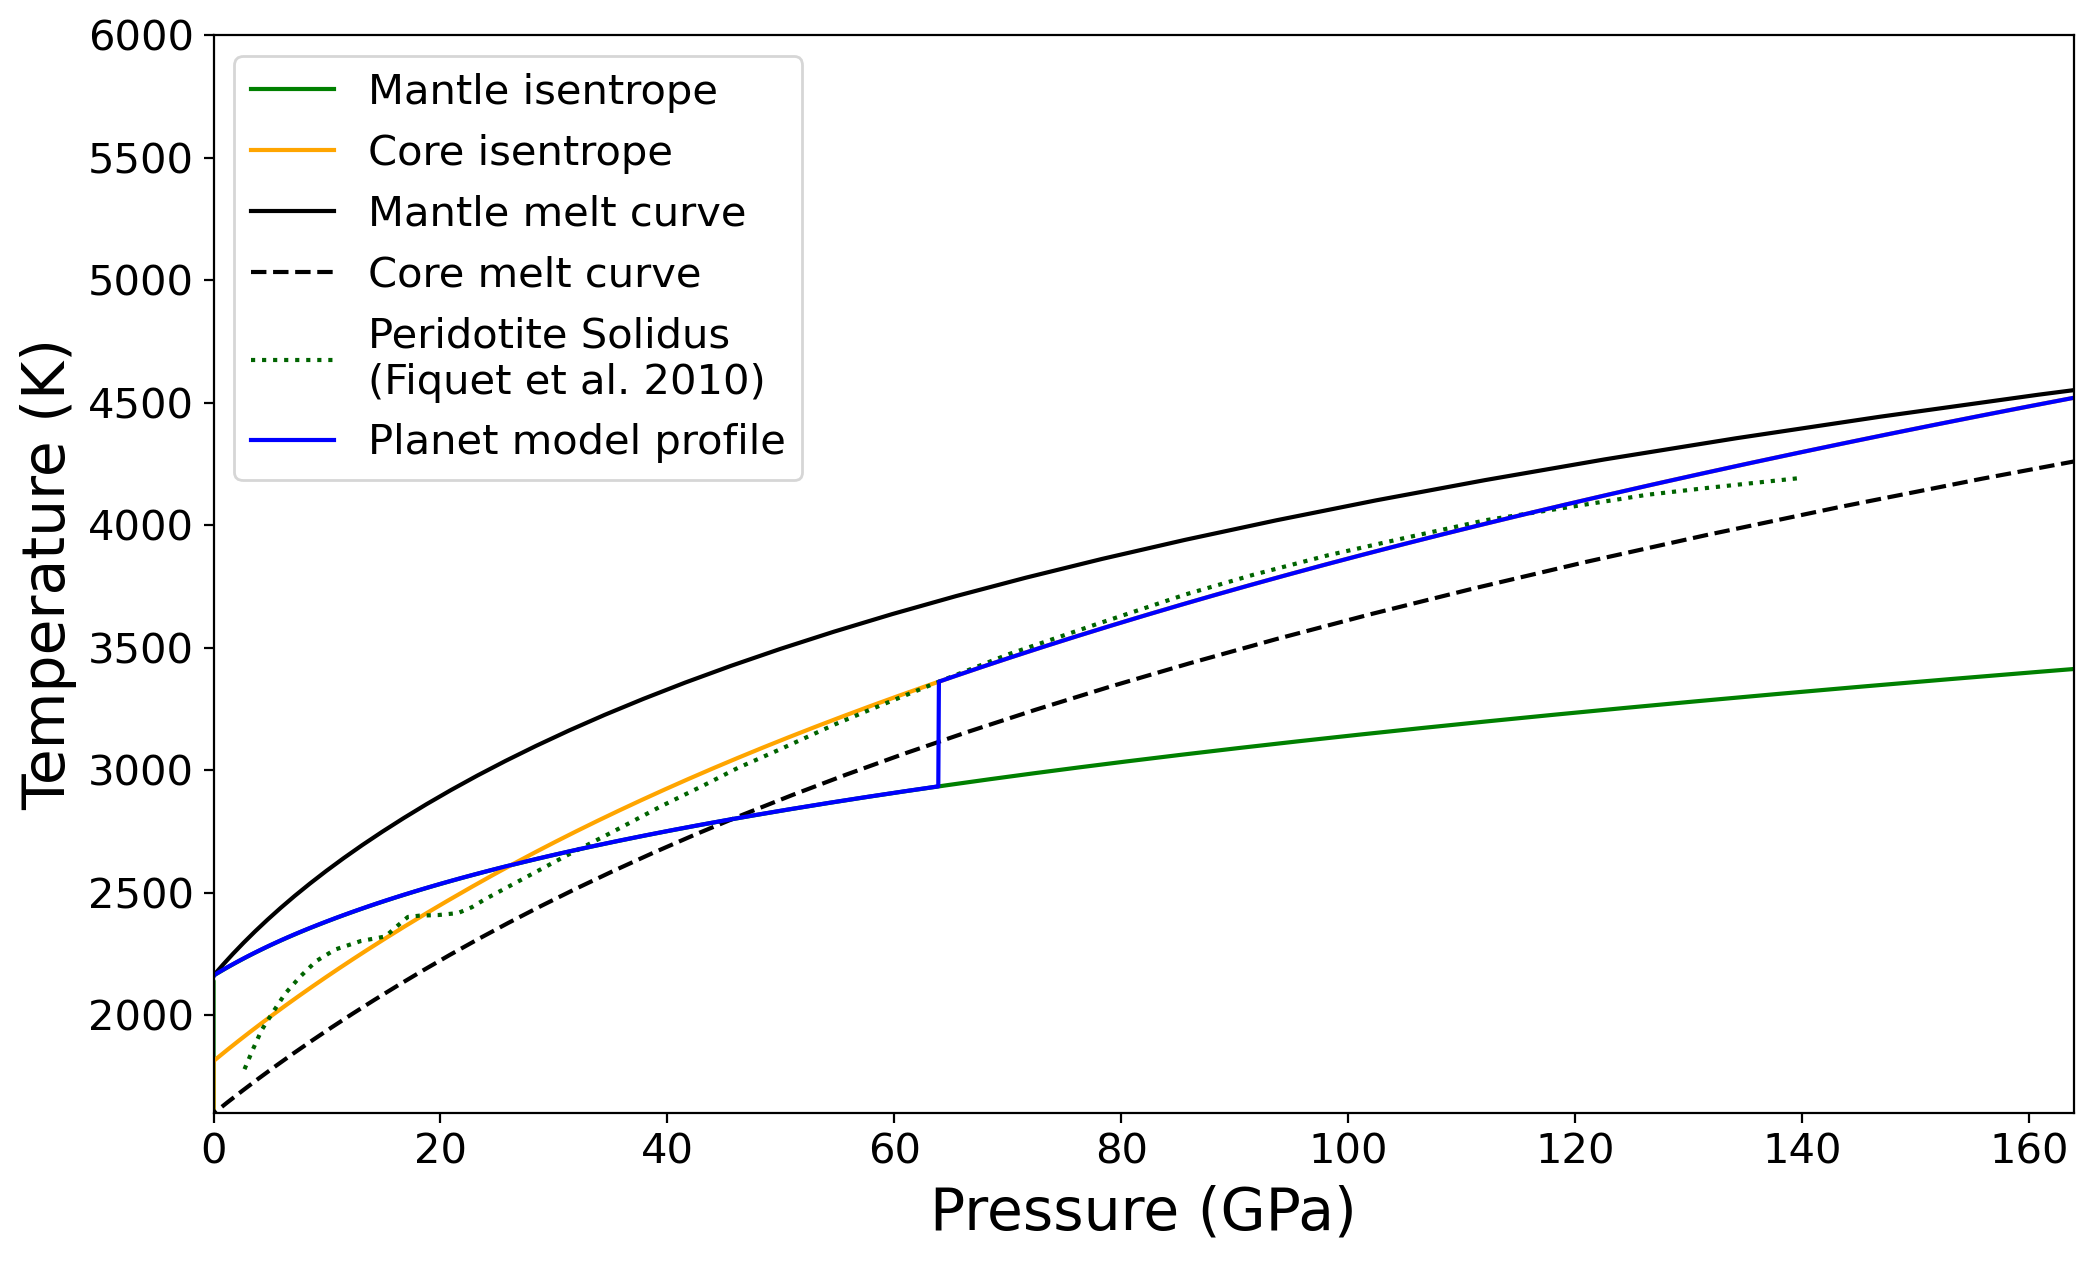

In [13]:
m0455planet = planet_profile()
m0455planet.load(file='./planet_profiles/M0.455PyroSCwarmSMwarmN67_fulltension.txt')
m0455planet.convert_to_cgs()
core=isentrope_class(entropy=1.81782463)
mantle=isentrope_class(entropy=2.82010204)
plot_PT_profile(m0455planet,core,mantle,coreEOS='alloy',mantleEOS='pyrolite')

## Figure 3

Planet mass: 1.8989924820842543


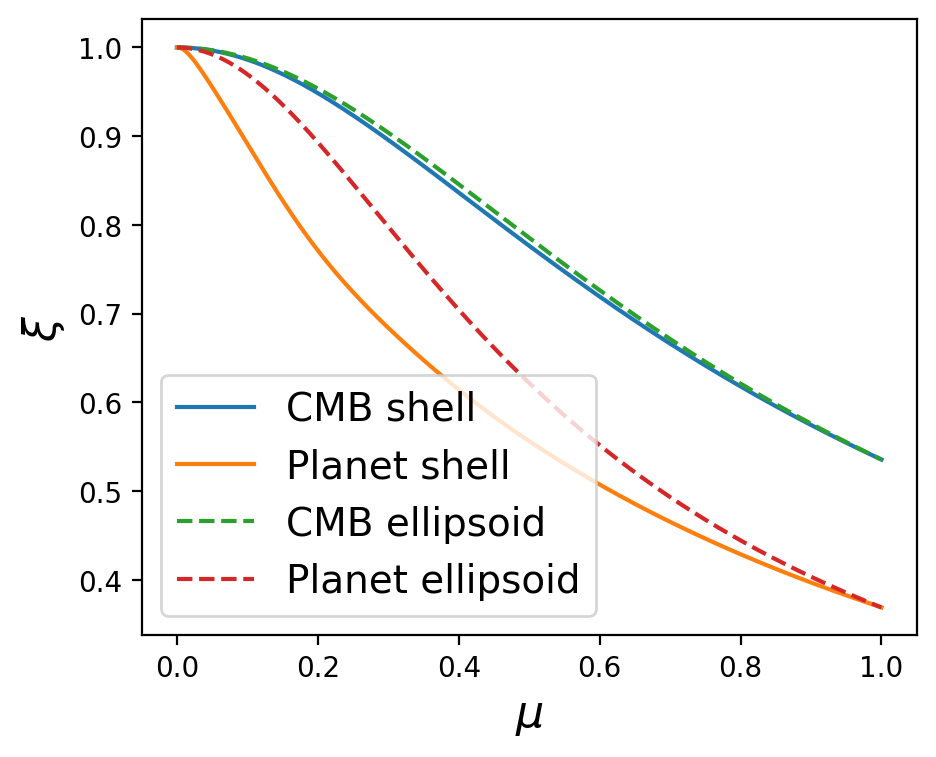

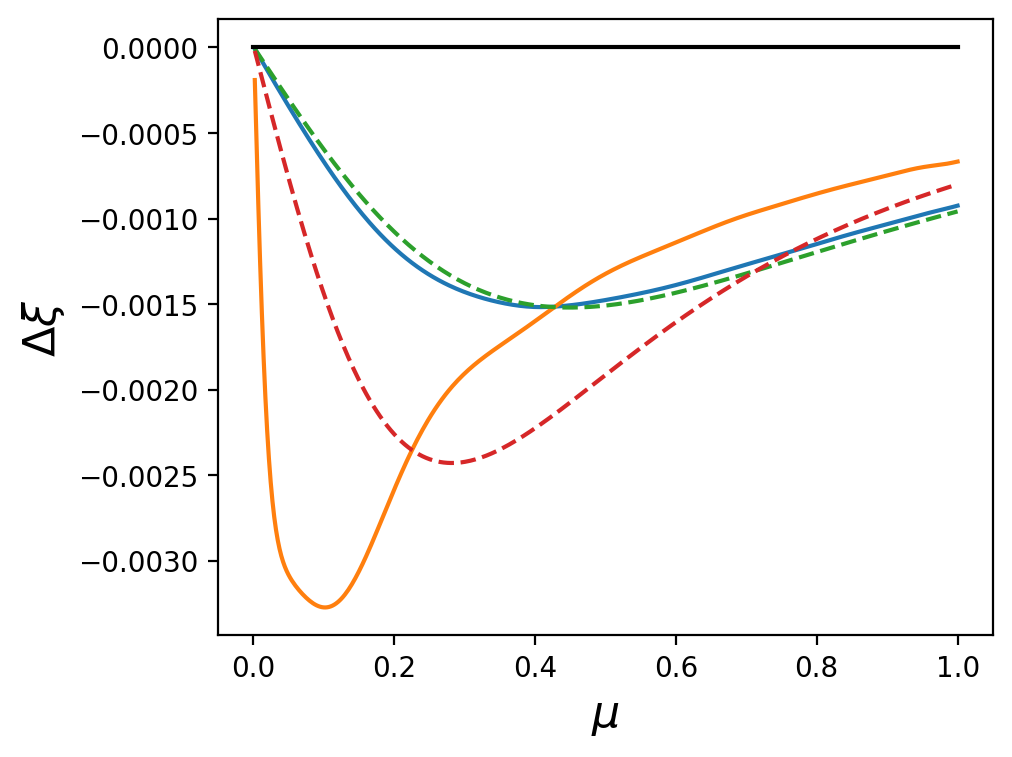

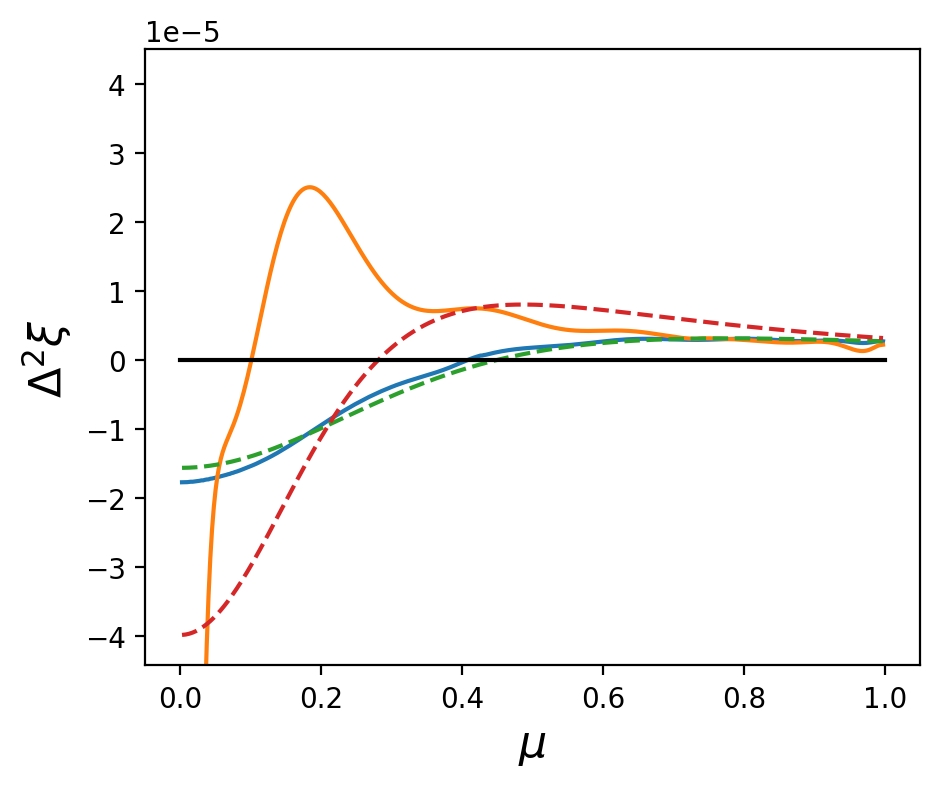

In [14]:
## REPLACE KEYLIST[i] WITH ANY VALUE 0-24 TO SEE AN HERCULES COROL-FINDING METHOD FOR A GIVEN MASS
key=hercdict[keylist[24]]
print("Planet mass:",key.M/M_earth)
keparr=np.array([])

def xi_ellipsoid(mu,a,b):
    return b/np.sqrt(b**2-b**2*mu**2+a**2*mu**2)

for i in range(np.size(key.Ltot)):
    #print(key.keys)
    p=key.planetdict[key.keys[i]]
    radius=np.empty(p.Nlayer)
    for k in np.arange(p.Nlayer):
        radius[k]=p.layers[k].a
    dVdr=gradient2(radius, p.Ulayers-(((radius*p.omega_rot)**2)/2.0))
    temp=np.sqrt(-1.0*dVdr/radius)
    keparr=np.append(keparr,temp[0])
    if i==np.size(key.Ltot)-1:
        #x=p.layers[0].xi*p.layers[0].a*np.sqrt(np.absolute(1-p2.layers[0].mu**2))/1E6
        #plt.plot(radius,temp)
        #plt.show()
        core_layer=p.Nmaterial-1
        temp=np.where(p.flag_material==core_layer)[0]
        ind=temp[0]
        #ind=0
        ai=p.layers[ind].a
        a0=p.layers[0].a
        bi=p.layers[ind].a*p.layers[ind].xi[-1]
        b0=p.layers[0].a*p.layers[0].xi[-1]
        plt.figure(figsize=(5,4))
        plt.plot(p.layers[ind].mu,p.layers[ind].xi,label='CMB shell')
        plt.plot(p.layers[0].mu,p.layers[0].xi,label='Planet shell')
        plt.plot(p.layers[ind].mu,xi_ellipsoid(p.layers[ind].mu,ai,bi),label='CMB ellipsoid',ls='--')
        plt.plot(p.layers[0].mu,xi_ellipsoid(p.layers[0].mu,a0,b0),label='Planet ellipsoid',ls='--')
        plt.xlabel(r'$\mu$',fontsize=16)
        plt.ylabel(r'$\xi$',fontsize=16)
        plt.legend(fontsize=14)
        imname='muxi1'+'.pdf'
        plt.savefig(imname,bbox_inches='tight')
        plt.show()
        plt.figure(figsize=(5,4))
        plt.plot(p.layers[ind].mu[1:],np.diff(p.layers[ind].xi))
        plt.plot(p.layers[0].mu[1:],np.diff(p.layers[0].xi))
        plt.plot(p.layers[ind].mu[1:],np.diff(xi_ellipsoid(p.layers[ind].mu,ai,bi)),ls='--')
        plt.plot(p.layers[0].mu[1:],np.diff(xi_ellipsoid(p.layers[0].mu,a0,b0)),ls='--')
        plt.plot(p.layers[ind].mu,np.zeros(np.size(p.layers[ind].mu)),color='k')
        plt.xlabel(r'$\mu$',fontsize=16)
        plt.ylabel(r'$\Delta\xi$',fontsize=16)
        imname='muxi2'+'.pdf'
        plt.savefig(imname,bbox_inches='tight')
        plt.show()
        plt.figure(figsize=(5,4))
        plt.plot(p.layers[ind].mu[1:-1],np.diff(p.layers[ind].xi,n=2))
        plt.plot(p.layers[0].mu[1:-1],np.diff(p.layers[0].xi,n=2))
        plt.plot(p.layers[ind].mu[1:-1],np.diff(xi_ellipsoid(p.layers[ind].mu,ai,bi),n=2),ls='--')
        plt.plot(p.layers[0].mu[1:-1],np.diff(xi_ellipsoid(p.layers[0].mu,a0,b0),n=2),ls='--')
        plt.plot(p.layers[ind].mu,np.zeros(np.size(p.layers[ind].mu)),color='k')
        plt.ylim(2.5*np.diff(p.layers[ind].xi,n=2)[0],None)
        plt.xlabel(r'$\mu$',fontsize=16)
        plt.ylabel(r'$\Delta^2\xi$',fontsize=16)
        imname='muxi3'+'.pdf'
        plt.savefig(imname,bbox_inches='tight')
        plt.show()


## Figure 4

In [15]:
fnames=['./output/M.0017PyroSCmantleSMwarm_L0.00012447_N200_Nm400_k6_f021_p0.1_l1_0_1.5_final',
    './output/M.005PyroSCmantleSMwarm_L0.000746107_N150_Nm400_k6_f121_p1_l1_0_1.5_final',
    './output/M.017PyroSCmantleSMwarm_L0.00556398_N200_Nm400_k6_f021_p1_l1_0_1.5_final',
    './output/M.05PyroSCmantleSMwarm_L0.0338559_N200_Nm400_k6_f021_p10_l1_0_1.5_final',
    './output/M0.17PyroSCmantleSMwarm_L0.239186_N150_Nm400_k6_f021_p10_l1_0_1.5_final',
    './output/M0.55PyroSCwarmSMwarm_L1.61451_N150_Nm400_k6_f121_p10_l1_0_1.5_final',
    './output/M0.91PyroSCwarmSMwarm_L3.56832_N150_Nm400_k6_f121_p10_l1_0_1.5_final',
    './output/M1.9PyroSCmeltSMwarm_L11.2282_N200_Nm400_k6_f021_p10_l1_0_1.5_final'
    ]

filelist = np.array([])
masslist = np.array([])
planetdict2 = {}
hercdict2 = {}
for filename in fnames:
    tparams = HERCULES_parameters()
    tparams.flag_output_format=1
    tparams.thermo_var_output=['T','S','E']
    tplanet = HERCULES_planet()
    tplanet.flag_output_format=1
    tplanet.thermo_var_output=['T','S','E']
    try:   
        try:
            with open(filename, "rb") as file:
                tparams.read_binary(file)
                tplanet.read_binary(file,1,['T','S','E'])
        except:
            print('ERROR: READ WITH FORMAT 1 UNSUCCESSFUL')
            tparams.flag_output_format=0
            tplanet.flag_output_format=0
            with open(filename, "rb") as file:
                tparams.read_binary(file)
                tplanet.read_binary(file,0,['T','S','E'])

        tplanet.calc_pCMB()
        print('Loaded HERCULES output ',filename)
        #self.keys=np.append(self.keys,keyparams)
        #self.paramsdict[keyparams]=tparams
        #self.planetdict[keyparams]=tplanet
        #self.Ltot=np.append(self.Ltot,tplanet.Ltot)
        #self.PCMB=np.append(self.PCMB,tplanet.pCMB)
        #self.Pcore=np.append(self.Pcore,tplanet.pcore)
        #self.r1=np.append(self.r1,tplanet.amax)
        #self.w=np.append(self.w,tplanet.omega_rot)
        #core_layer=tplanet.Nmaterial-1
        #ind=np.where(tplanet.flag_material==core_layer)[0]
        #self.rCMB=np.append(self.rCMB,tplanet.layers[ind[0]].a)
        hercdict2[filename]=tplanet
    except:
        print('ERROR: READ UNSUCCESSFUL. SKIPPING FILE')
        

PARAM FORMAT 1
PARAM READ SUCCESSFUL WITH FORMAT 1
OUTPUT FORMAT 1
OUTPUT READ SUCCESSFUL WITH FORMAT 1
Loaded HERCULES output  ./output/M.0017PyroSCmantleSMwarm_L0.00012447_N200_Nm400_k6_f021_p0.1_l1_0_1.5_final
PARAM FORMAT 1
ERROR: READ WITH FORMAT 1 UNSUCCESSFUL
PARAM FORMAT 0
PARAM READ SUCCESSFUL WITH FORMAT 0
OUTPUT FORMAT 0
OUTPUT READ SUCCESSFUL WITH FORMAT 0
Loaded HERCULES output  ./output/M.005PyroSCmantleSMwarm_L0.000746107_N150_Nm400_k6_f121_p1_l1_0_1.5_final
PARAM FORMAT 1
PARAM READ SUCCESSFUL WITH FORMAT 1
OUTPUT FORMAT 1
OUTPUT READ SUCCESSFUL WITH FORMAT 1
Loaded HERCULES output  ./output/M.017PyroSCmantleSMwarm_L0.00556398_N200_Nm400_k6_f021_p1_l1_0_1.5_final
PARAM FORMAT 1
PARAM READ SUCCESSFUL WITH FORMAT 1
OUTPUT FORMAT 1
OUTPUT READ SUCCESSFUL WITH FORMAT 1
Loaded HERCULES output  ./output/M.05PyroSCmantleSMwarm_L0.0338559_N200_Nm400_k6_f021_p10_l1_0_1.5_final
PARAM FORMAT 1
ERROR: READ WITH FORMAT 1 UNSUCCESSFUL
PARAM FORMAT 0
PARAM READ SUCCESSFUL WITH FORMAT 

In [16]:
## writing code for volume scaling
volume=0
j=0
p=hercdict2[fnames[0]]
for i in range(1,np.size(p.layers[j].xi)):
    dy=p.layers[j].xi[i]*p.layers[j].a*p.layers[j].mu[i]/1E6-p.layers[j].xi[i-1]*p.layers[j].a*p.layers[j].mu[i-1]/1E6
    x=p.layers[j].xi[i-1]*p.layers[j].a*np.sqrt(np.absolute(1-p.layers[j].mu[i-1]**2))/1E6
    v=np.pi*x**2*dy
    volume+=v
print(volume)
v1=volume

1.5114077606842744


In [17]:
vfracdict={}
for filename in fnames:
    ## writing code for volume scaling
    volume1=0
    p2=hercdict2[filename]
    for i in range(1,np.size(p.layers[j].xi)):
        dy=p2.layers[j].xi[i]*p2.layers[j].a*p2.layers[j].mu[i]/1E6-p2.layers[j].xi[i-1]*p2.layers[j].a*p2.layers[j].mu[i-1]/1E6
        #dy/=vfrac
        x=p2.layers[j].xi[i-1]*p2.layers[j].a*np.sqrt(np.absolute(1-p2.layers[j].mu[i-1]**2))/1E6
        #x/=vfrac
        v=np.pi*x**2*dy
        volume1+=v
    print(volume1)
    vfrac=(volume1/v1)**(1/3)
    vfracdict[filename]=vfrac
    volume2=0
    j=0
    for i in range(1,np.size(p.layers[j].xi)):
        dy=p2.layers[j].xi[i]*p2.layers[j].a*p2.layers[j].mu[i]/1E6-p2.layers[j].xi[i-1]*p2.layers[j].a*p2.layers[j].mu[i-1]/1E6
        dy/=vfrac
        x=p2.layers[j].xi[i-1]*p2.layers[j].a*np.sqrt(np.absolute(1-p2.layers[j].mu[i-1]**2))/1E6
        x/=vfrac
        v=np.pi*x**2*dy
        volume2+=v
    print(volume2)

1.5114077606842744
1.5114077606842744
4.513170897905668
1.511407760684274
14.95096179767695
1.5114077606842773
44.177527765679756
1.5114077606842717
142.3278639146324
1.5114077606842724
438.3488445928325
1.511407760684275
693.1634870018162
1.5114077606842737
1318.9876843427078
1.5114077606842715


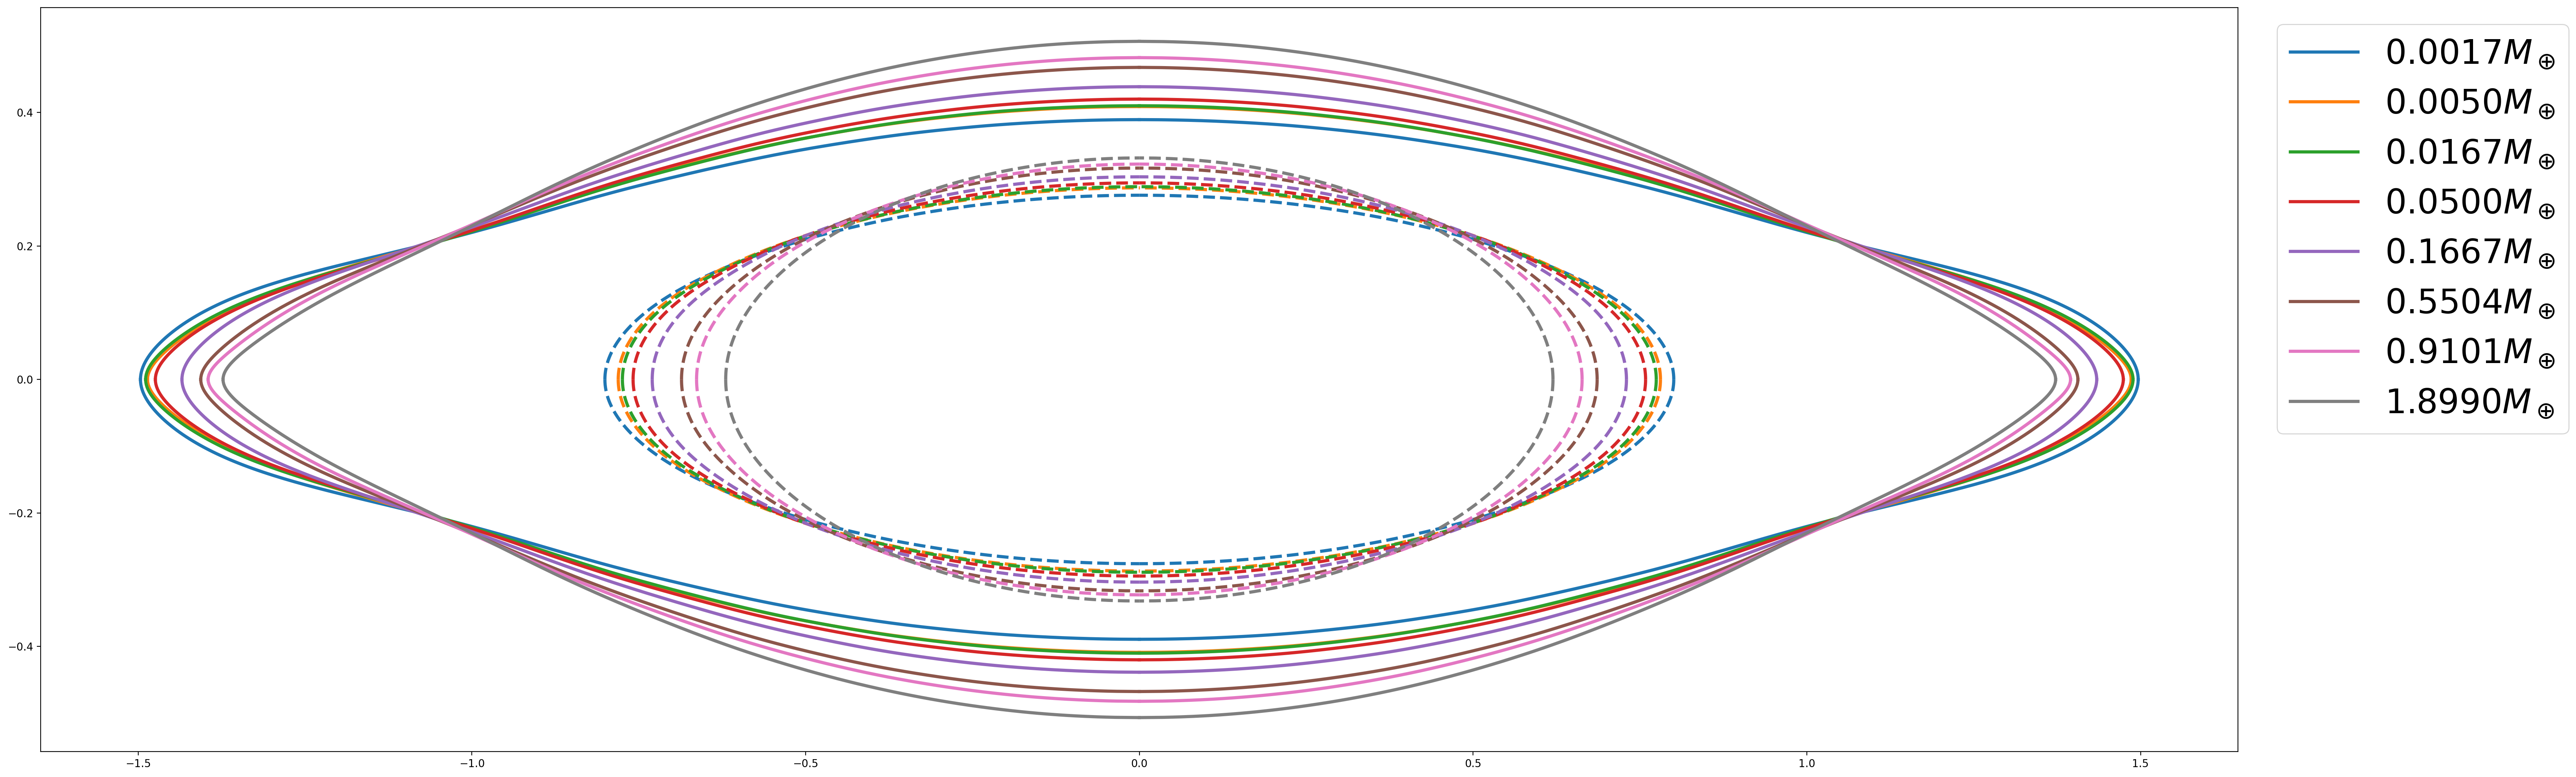

In [18]:
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']


fig,ax=plt.subplots(1,1,figsize=[34,17])
i=0
for filename in fnames:
    p2=hercdict2[filename]
    vfrac=vfracdict[filename]
    core_layer=p2.Nmaterial-1
    temp=np.where(p2.flag_material==core_layer)[0]
    ind=temp[0]
    ax.plot(p2.layers[ind].xi*p2.layers[ind].a*np.sqrt(np.absolute(1-p2.layers[ind].mu**2))/1E6/vfrac, p2.layers[ind].xi*p2.layers[ind].a*p2.layers[ind].mu/1E6/vfrac, '--', c=colors[i], linewidth=3)
    ax.plot(p2.layers[ind].xi*p2.layers[ind].a*np.sqrt(np.absolute(1-p2.layers[ind].mu**2))/-1E6/vfrac, p2.layers[ind].xi*p2.layers[ind].a*p2.layers[ind].mu/1E6/vfrac, '--', c=colors[i], linewidth=3)
    ax.plot(p2.layers[ind].xi*p2.layers[ind].a*np.sqrt(np.absolute(1-p2.layers[ind].mu**2))/1E6/vfrac, p2.layers[ind].xi*p2.layers[ind].a*p2.layers[ind].mu/-1E6/vfrac, '--', c=colors[i], linewidth=3)
    ax.plot(p2.layers[ind].xi*p2.layers[ind].a*np.sqrt(np.absolute(1-p2.layers[ind].mu**2))/-1E6/vfrac, p2.layers[ind].xi*p2.layers[ind].a*p2.layers[ind].mu/-1E6/vfrac, '--', c=colors[i], linewidth=3)
    
    ax.plot(p2.layers[0].xi*p2.layers[0].a*np.sqrt(np.absolute(1-p2.layers[0].mu**2))/1E6/vfrac, p2.layers[0].xi*p2.layers[0].a*p2.layers[0].mu/1E6/vfrac, '-', c=colors[i], linewidth=3,label=r'%.4f$M_\oplus$'%(p2.Mtot/M_earth))
    ax.plot(p2.layers[0].xi*p2.layers[0].a*np.sqrt(np.absolute(1-p2.layers[0].mu**2))/-1E6/vfrac, p2.layers[0].xi*p2.layers[0].a*p2.layers[0].mu/1E6/vfrac, '-', c=colors[i], linewidth=3)
    ax.plot(p2.layers[0].xi*p2.layers[0].a*np.sqrt(np.absolute(1-p2.layers[0].mu**2))/1E6/vfrac, p2.layers[0].xi*p2.layers[0].a*p2.layers[0].mu/-1E6/vfrac, '-', c=colors[i], linewidth=3)
    ax.plot(p2.layers[0].xi*p2.layers[0].a*np.sqrt(np.absolute(1-p2.layers[0].mu**2))/-1E6/vfrac, p2.layers[0].xi*p2.layers[0].a*p2.layers[0].mu/-1E6/vfrac, '-', c=colors[i], linewidth=3)
    
    i+=1
ax.legend(fontsize=32,bbox_to_anchor=(1.01, 1.0),)
ax.set_aspect('equal')
plt.tight_layout()
imname='corol_shape2'+'.pdf'
#plt.savefig(imname)
plt.show()

## Figure 5

In [19]:
#the path to the structure file you want to plot
fname='./output/M1.9PyroSCmeltSMwarm_L11.1331_N200_Nm400_k6_f021_p10_l1_0_1.5_final'
#fname='./output/M.0017PyroSCmantleSMwarm_L0.000102862_N150_Nm400_k6_f021_p0.1_l1_0_1.5_final'

###############################################################
#define blank planet and parameter classes
params=HERCULES_parameters()
params.flag_output_format=1
params.thermo_var_output=['T','S','E']
p=HERCULES_planet()

#read in HERCULES output
file = open(fname, "rb")
params.read_binary(file)
p.read_binary(file,1,['T','S','E'])
file.close()


PARAM FORMAT 1
PARAM READ SUCCESSFUL WITH FORMAT 1
OUTPUT FORMAT 1
OUTPUT READ SUCCESSFUL WITH FORMAT 1


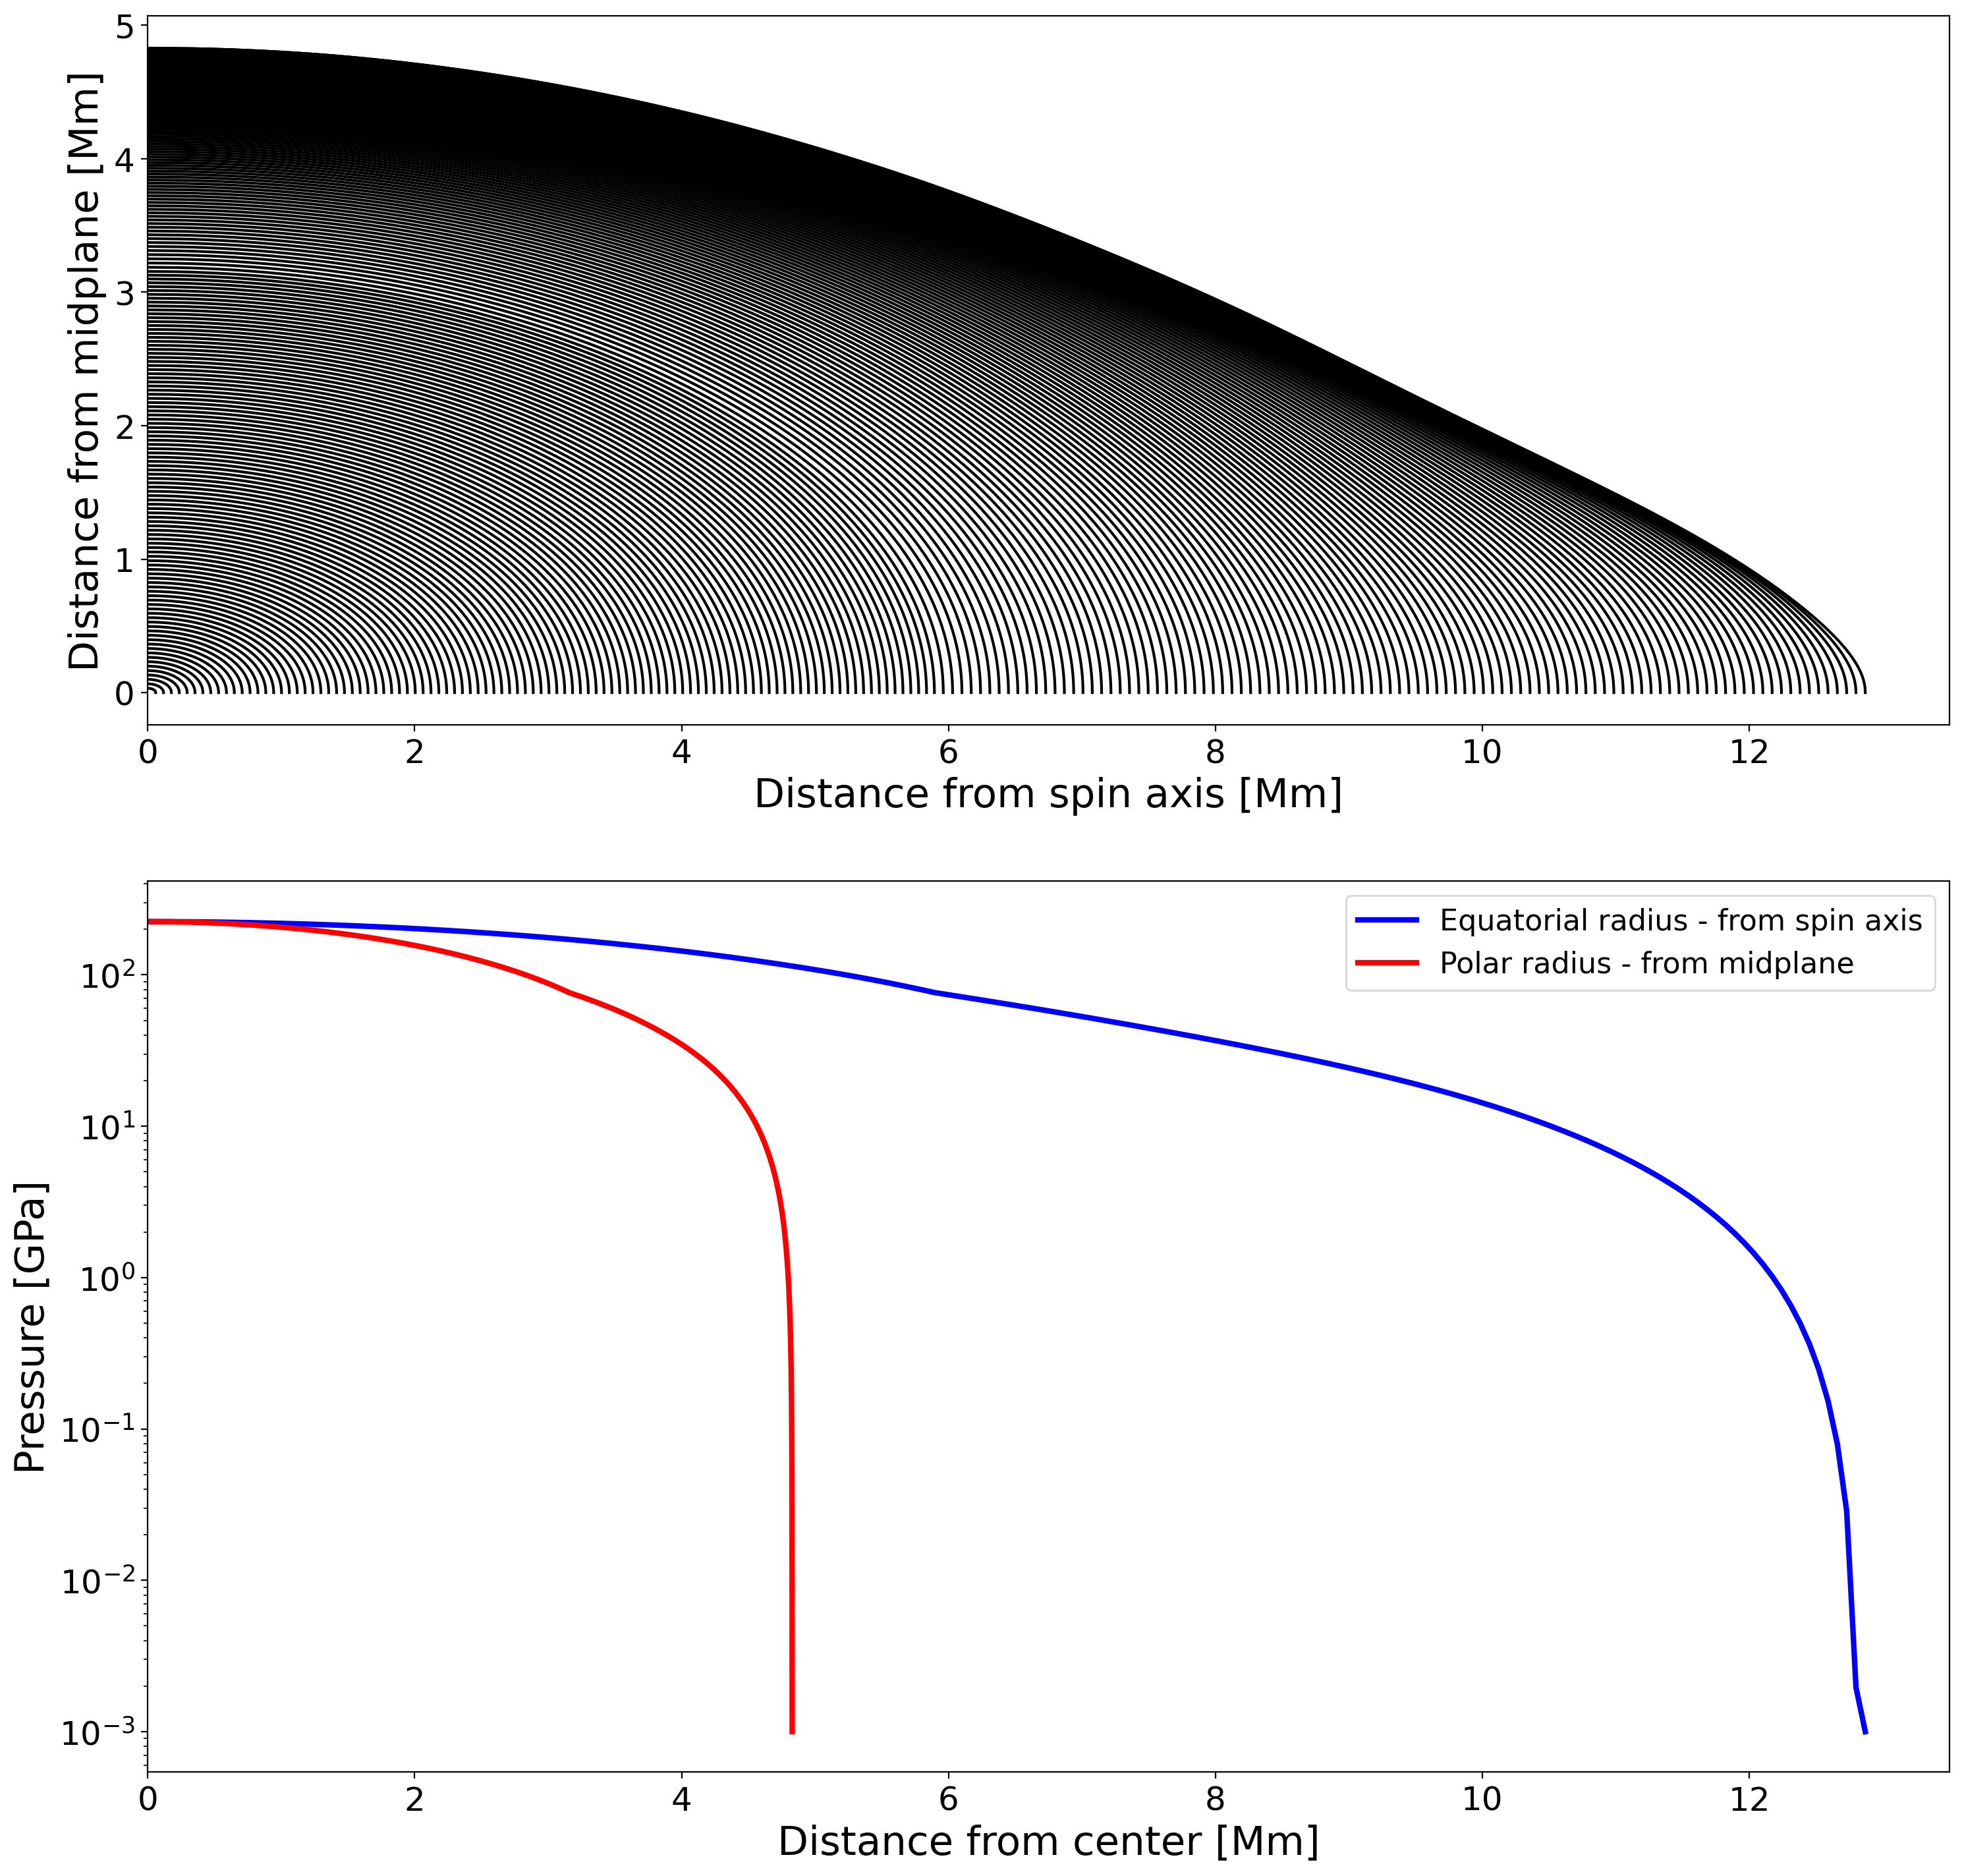

In [20]:
fig,ax=plt.subplots(2,1,figsize=[15,15])

matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14)


for i in np.arange(0, p.Nlayer):
    ax[0].plot(p.layers[i].xi*p.layers[i].a*np.sqrt(np.absolute(1-p.layers[i].mu**2))/1E6, p.layers[i].xi*p.layers[i].a*p.layers[i].mu/1E6, '-', color='k', linewidth=1.5)
ax[0].set_xlim([0,13.5])
ax[0].set_aspect('equal')
#plt.setp(ax[0].get_xticklabels(), visible=True)
ax[0].set_ylabel('Distance from midplane [Mm]',size=22)
ax[0].set_xlabel('Distance from spin axis [Mm]',size=22)
#ax1.hold(False)    
ax[0].tick_params(axis='both', which='major', labelsize=18)
ax[0].tick_params(axis='both', which='minor', labelsize=18)

#plot the pressure profile
radius=np.asarray([])
radius2=np.asarray([])
press=np.asarray([])
for i in np.arange(p.Nlayer):
    radius=np.append(radius, np.asarray(p.layers[i].a/1.0E6))
    radius2=np.append(radius2,np.asarray(p.layers[i].b/1.0E6))
    press=np.append(press, np.asarray(p.press[i]/1.0E9))
radius=np.append(radius, np.asarray(0.0))
radius2=np.append(radius2, np.asarray(0.0))
press=np.append(press, np.asarray(p.pcore/1.0E9))

#ax2.hold(True)
ax[1].plot(radius, press, '-', color='blue', linewidth=3,label='Equatorial radius - from spin axis')
ax[1].plot(radius2, press, '-', color='red', linewidth=3,label='Polar radius - from midplane')

ax[1].set_xlim([0,13.5])
#ax[1].set_ylim(1.e-5,None)
ax[1].set_yscale('log')
ax[1].set_xlabel('Distance from center [Mm]',size=22)
ax[1].set_ylabel('Pressure [GPa]',size=22)
#ax2.hold(False)
ax[1].tick_params(axis='both', which='major', labelsize=18)
ax[1].tick_params(axis='both', which='minor', labelsize=18)
ax[1].legend(fontsize=16)



plt.tight_layout()
imname='corol_P_profile_both'+'.pdf'
#plt.savefig(imname)
plt.show()

## *See Mathematica notebook for Figure 6*

In [21]:
cubfitdict=dict()
quartfitdict=dict()
for i in keylist:
    key=hercdict[i]
    coeffs=np.polyfit(key.Ltot/LEM,key.PCMB/1.e9,3)
    cubfitdict[i]=coeffs
    coeffs=np.polyfit(key.Ltot/LEM,key.PCMB/1.e9,4)
    quartfitdict[i]=coeffs

In [22]:
def write_coeffs(testdict,hercdict=hercdict,keylist=keylist):
    fitsize=np.size(testdict[keylist[0]])
    for j in range(fitsize):
        str1='fitdeg%d'%(fitsize-1)
        str2='_k%d'%(fitsize-1-j)
        fname=str1+str2
        with open(fname+'.csv','w') as wfile:
            for i in keylist:
                key=hercdict[i]
                wfile.write('%.9e'%(key.M/M_earth)+','+'%.9e'%np.log(np.abs(testdict[i][j]))+'\n')

In [23]:
## Writing files to help Mathematica describe a fit

write_coeffs(cubfitdict)

In [24]:
with open('alldataML'+'.csv','w') as wfile:
    for i in keylist:
        key=hercdict[i]
        print(key.M/M_earth)
        for j in range(np.size(key.Ltot)):
            if key.Ltot[j]/LEM<CoRoLinterp(key.M/M_earth):
                wfile.write('%.9e'%(key.M/M_earth)+','+'%.9e'%(key.Ltot[j]/LEM)+','+'%.9e'%(key.PCMB[j]/1.e9)+'\n')

0.001667078114325899
0.0033328373518183648
0.004999976776505257
0.010007283755274262
0.01668026595673431
0.03332227848101266
0.050025178320273256
0.05499963281093027
0.08336844585091421
0.10006790670417252
0.1517723913334673
0.16672166683410355
0.2166383263009845
0.25007144364074746
0.303408095572969
0.43344730426629163
0.45499484461857875
0.5004180781595339
0.55041936909785
0.650453482687027
0.7061969878105955
0.9101278849373786
1.298940668742884
1.4994135841537741
1.8989924820842543


## Figure 7

0.0017$M_\oplus$ 0.31344805315058644
0.0033$M_\oplus$ 0.31254220002388217
0.0050$M_\oplus$ 0.3385477678902574
0.0100$M_\oplus$ 0.3291680797554339
0.0167$M_\oplus$ 0.3274032719475516
0.0333$M_\oplus$ 0.3364733848586786
0.0500$M_\oplus$ 0.336156633646503
0.0550$M_\oplus$ 0.3348369363541671
0.0834$M_\oplus$ 0.34403694562526566
0.1001$M_\oplus$ 0.34366406871279565
0.1518$M_\oplus$ 0.35491378434899107
0.1667$M_\oplus$ 0.34299104229163135
0.2166$M_\oplus$ 0.3488427655837085
0.2501$M_\oplus$ 0.3425013129732146
0.3034$M_\oplus$ 0.3420521211975196
0.4334$M_\oplus$ 0.3359876304749584
0.4550$M_\oplus$ 0.3561215526967207
0.5004$M_\oplus$ 0.3568260289405984
0.5504$M_\oplus$ 0.35309226868228283
0.6505$M_\oplus$ 0.3755391210284935
0.7062$M_\oplus$ 0.3338240691480665
0.9101$M_\oplus$ 0.34907980715058967
1.2989$M_\oplus$ 0.34713908306268554
1.4994$M_\oplus$ 0.3588321319183169
1.8990$M_\oplus$ 0.3497732302634513


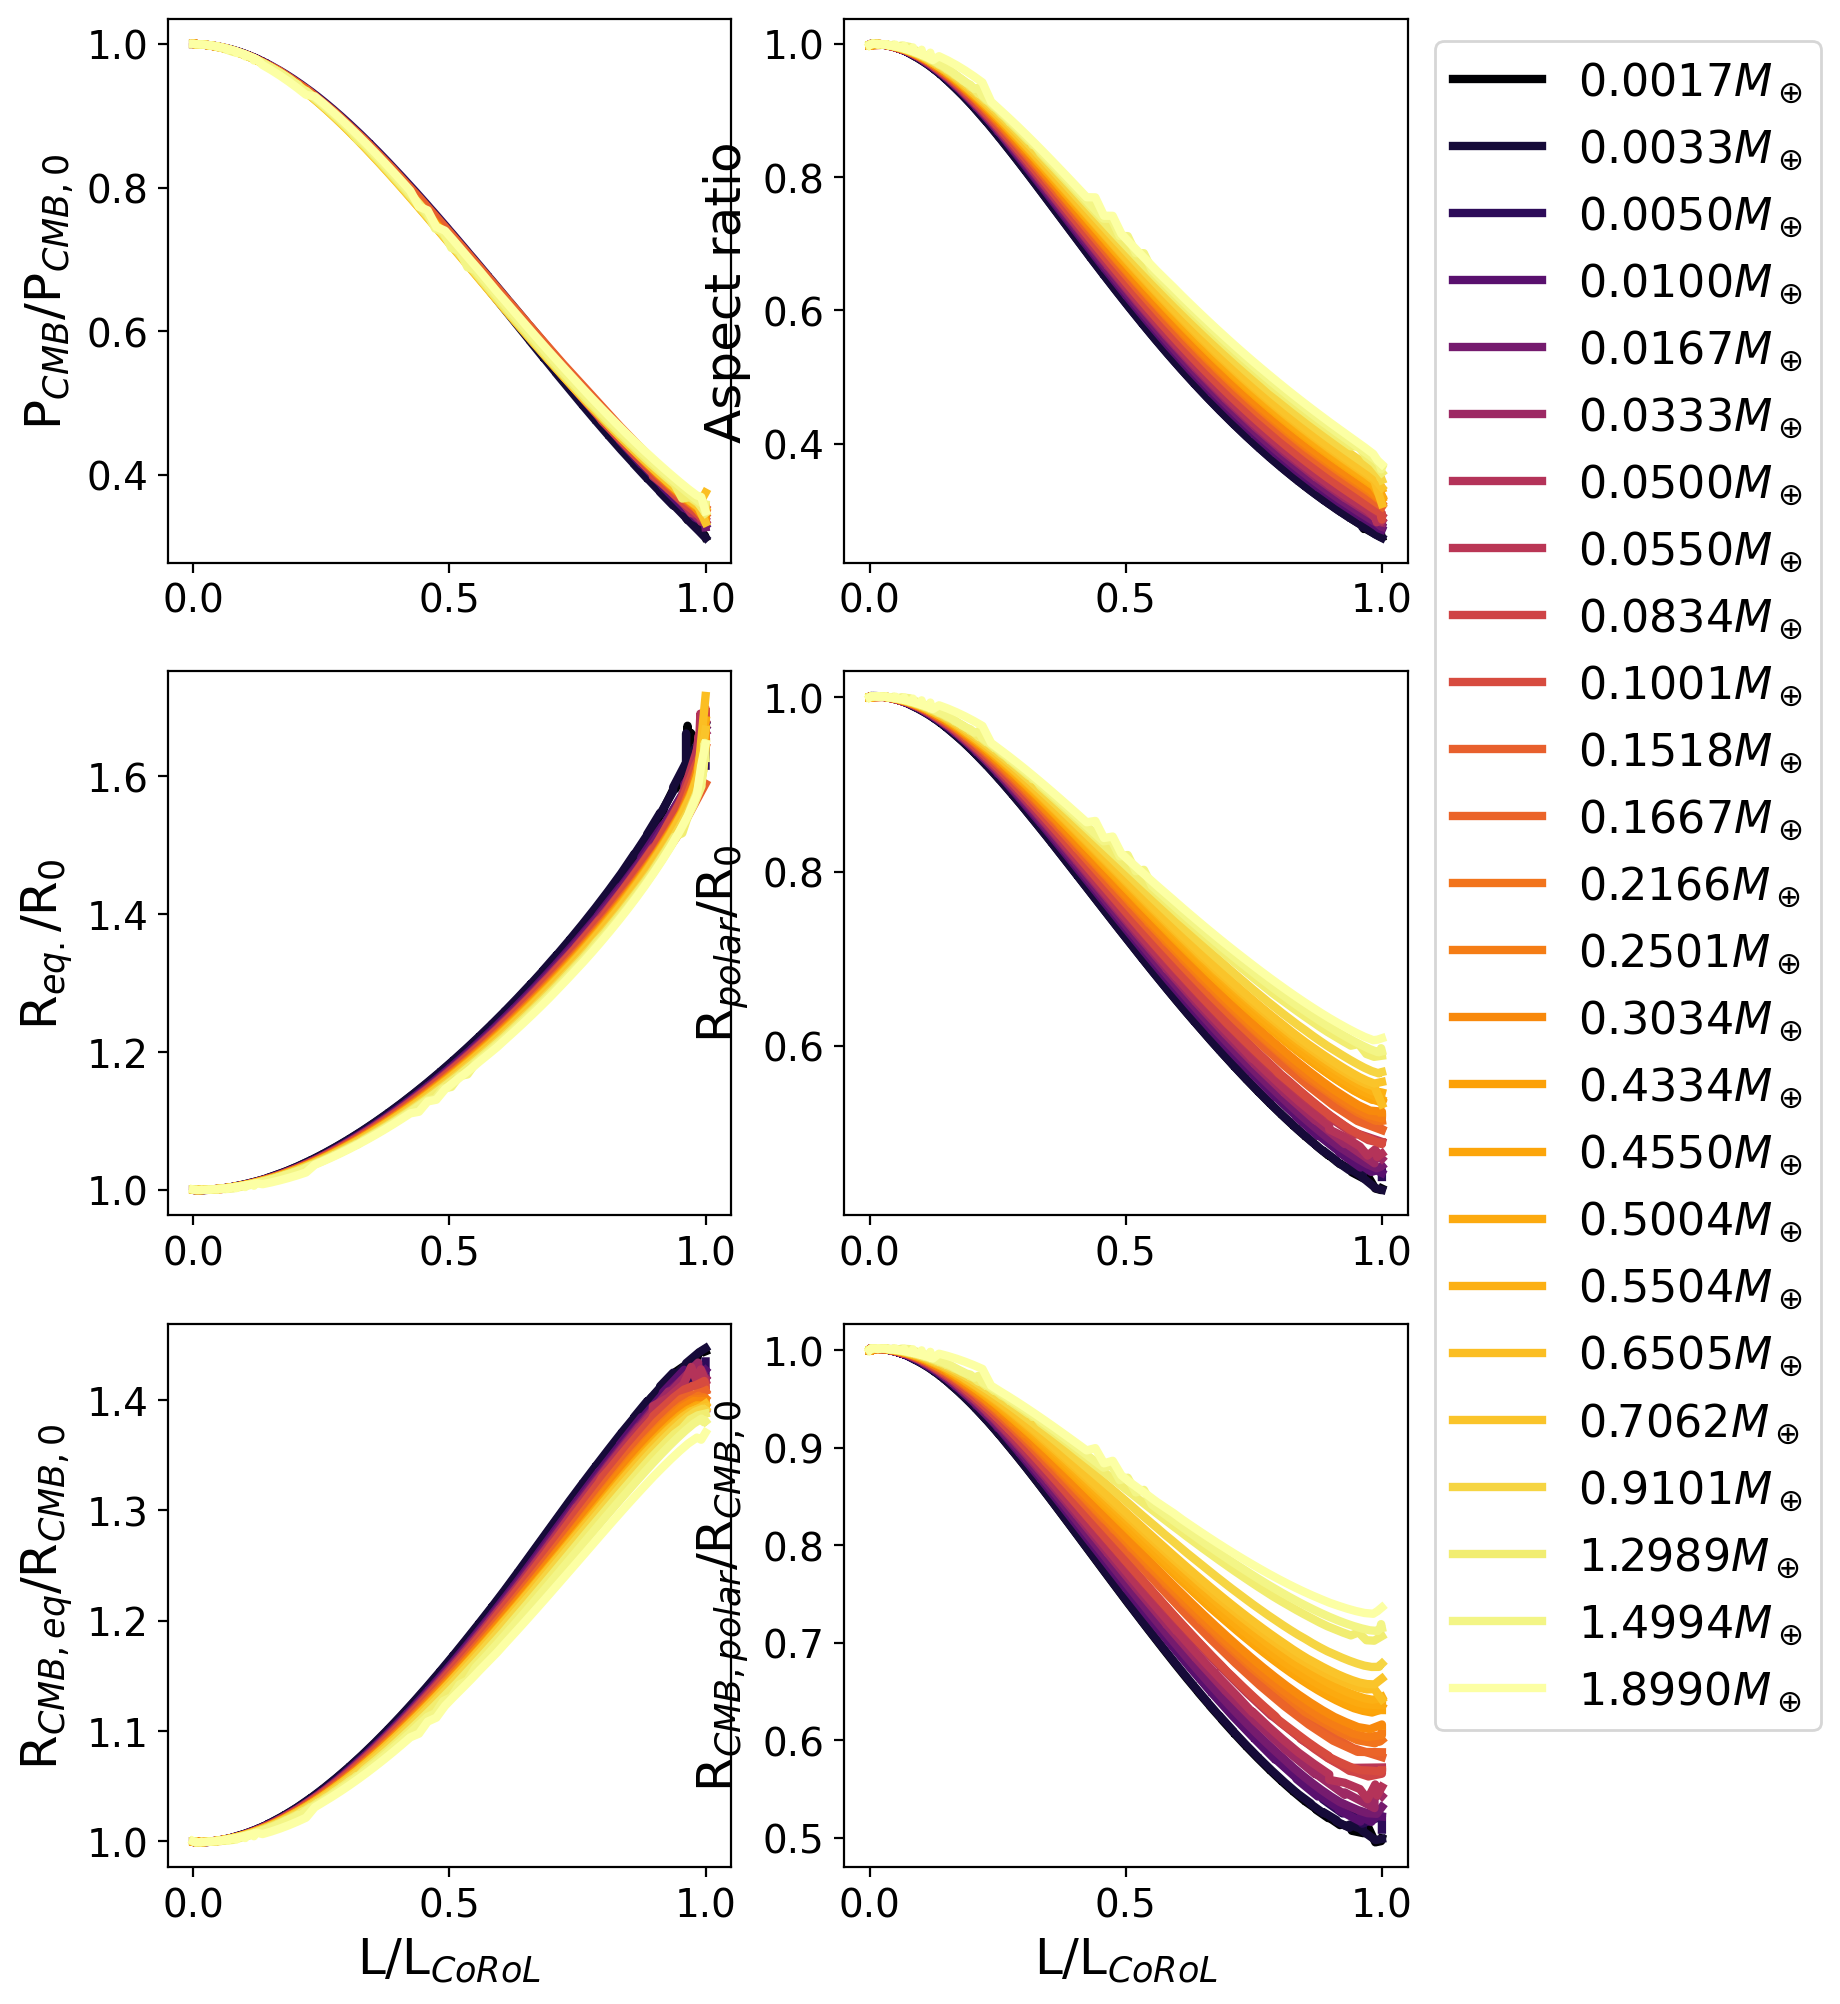

In [25]:
fig,ax=plt.subplots(3,2,figsize=[8,12])
norm=matplotlib.colors.LogNorm(vmin=hercdict[keylist[0]].M/M_earth,vmax=hercdict[keylist[-1]].M/M_earth)
cmap=matplotlib.colormaps['inferno']
for i in keylist:
    key=hercdict[i]
    label='%.4f$M_\oplus$'%(key.M/M_earth)
    print(label, key.PCMB[-1]/key.PCMB[0])
    #print(key.Ltot[-1])
    aspectarr=np.array([])
    eqarr=np.array([])
    CMBpolar=np.array([])
    polararr=np.array([])
    ind=np.where(key.planetdict[key.keys[0]].flag_material>0)[0][0]
    CMBpolar0=key.planetdict[key.keys[0]].layers[ind].b
    for j in range(np.size(key.Ltot)):
        ind=np.where(key.planetdict[key.keys[j]].flag_material>0)[0][0]
        eqarr=np.append(eqarr,key.planetdict[key.keys[j]].layers[0].a/key.planetdict[key.keys[0]].layers[0].a)
        aspectarr=np.append(aspectarr,key.planetdict[key.keys[j]].aspect)
        CMBpolar=np.append(CMBpolar,key.planetdict[key.keys[j]].layers[ind].b/CMBpolar0)
        polararr=np.append(polararr,key.planetdict[key.keys[j]].layers[0].b/key.planetdict[key.keys[0]].layers[0].b)
    
    ax[0,0].plot(key.Ltot/(key.Ltot[-1]),key.PCMB/key.PCMB[0],label=label,c=cmap(norm(key.M/M_earth)),lw=3)
    ax[0,1].plot(key.Ltot/(key.Ltot[-1]),aspectarr,c=cmap(norm(key.M/M_earth)),lw=3,label=label)
    #ax[1,0].plot(key.Ltot/(key.Ltot[-1]),key.r1/key.r1[0],c=cmap(norm(key.M/M_earth)),lw=3,label=label)
    ax[1,0].plot(key.Ltot/(key.Ltot[-1]),eqarr,c=cmap(norm(key.M/M_earth)),lw=3,label=label)
    #ax[1,1].plot(key.Ltot/(key.Ltot[-1]),key.b1/key.b1[0],c=cmap(norm(key.M/M_earth)),lw=3)
    ax[1,1].plot(key.Ltot/(key.Ltot[-1]),polararr,c=cmap(norm(key.M/M_earth)),lw=3)
    #ax[1,1].plot(key.Ltot/(key.Ltot[-1]),key.aspect,c=cmap(norm(key.M/M_earth)),lw=3)
    ax[2,0].plot(key.Ltot/(key.Ltot[-1]),key.rCMB/key.rCMB[0],c=cmap(norm(key.M/M_earth)),lw=3)
    #ax[2,1].plot(key.Ltot/(key.Ltot[-1]),key.rCMB/key.bCMB,c=cmap(norm(key.M/M_earth)),lw=3)
    ax[2,1].plot(key.Ltot/(key.Ltot[-1]),CMBpolar,c=cmap(norm(key.M/M_earth)),lw=3)
    
    

ax[0,1].legend(fontsize=16,bbox_to_anchor=(1.01, 1.0),)
ax[2,1].set_xlabel(r'L/L$_{CoRoL}$',size=18)
ax[2,0].set_xlabel(r'L/L$_{CoRoL}$',size=18)
ax[0,0].set_ylabel(r'P$_{CMB}$/P$_{CMB,0}$',size=18)
ax[0,1].set_ylabel(r'Aspect ratio',size=18)
ax[1,0].set_ylabel(r'R$_{eq.}$/R$_0$',size=18)
ax[1,1].set_ylabel(r'R$_{polar}$/R$_0$',size=18)
ax[2,0].set_ylabel(r'R$_{CMB,eq}$/R$_{CMB,0}$',size=18)
ax[2,1].set_ylabel(r'R$_{CMB,polar}$/R$_{CMB,0}$',size=18)

imname='all_HERC_new'+'.pdf'
plt.tight_layout()
plt.savefig(imname,dpi=200,bbox_inches='tight')
plt.show()

## Figure 8

In [26]:
Lzstars=np.array([])

for i in keylist:
    #key=hercdict[i]
    planet=planetdict[i]
    Lzstars=np.append(Lzstars,planet.Lzstar)

In [27]:
### CODE FROM SIMON FOR KOKUBO FIGURE
#read in KG10 file
file_KG10="./Figure3_KG2010_realistic_accretion.txt"
KG10_M,KG10_omg_mean,KG10_omg_low_error,KG10_omg_high_error=np.loadtxt(file_KG10,skiprows=1,unpack=True,delimiter=',')
#KG10_M#*=M_earth
KG10_omg_mean/=(60*60)
KG10_omg_low_error/=(60*60)
KG10_omg_high_error/=(60*60)

rhoc=3000.0
prefac=0.4*((3.0/(4.0*np.pi*rhoc))**(2.0/3.0))*((KG10_M*M_earth)**(5.0/3.0))
#print(prefac)

KG10_L_mean=prefac*KG10_omg_mean
KG10_L_low_error=prefac*KG10_omg_low_error
KG10_L_high_error=prefac*KG10_omg_high_error
print(KG10_L_mean)
print()

xerr=np.zeros([2,np.size(KG10_L_mean)])
yerr=np.zeros([2,np.size(KG10_L_mean)])
for i in range(np.size(KG10_L_mean)):
    yerr[0,i]=KG10_L_low_error[i]
    yerr[1,i]=KG10_L_high_error[i]
#plt.figure(figsize=(6, 4), dpi=80)
#plt.plot(KG10_M,CoRoLinterp(KG10_M),color='red',label='CoRoL (this study)')

#plt.errorbar(KG10_M,KG10_L_mean/LEM,yerr/LEM,xerr/LEM,fmt='o',color='k',label='Kokubo & Genda 2010')
#plt.ylabel('Angular momentum ($L_{EM}$)',size=16)
#plt.xlabel('Planet mass ($M_\oplus$)',size=16)
#plt.gca().legend(fontsize=14)
##plt.ylim(None,4)
#imname='CoRoL_genda'+'.pdf'
#plt.savefig(imname,bbox_inches='tight')

[9.86025830e+33 1.75844879e+34 2.62202341e+34 2.86736525e+34
 4.12117958e+34 5.31969137e+34 7.65362454e+34 8.15306727e+34
 9.56719245e+34 1.08946559e+35 1.16211600e+35 1.89519703e+35
 1.30269005e+35 2.39640880e+35 1.91249048e+35]



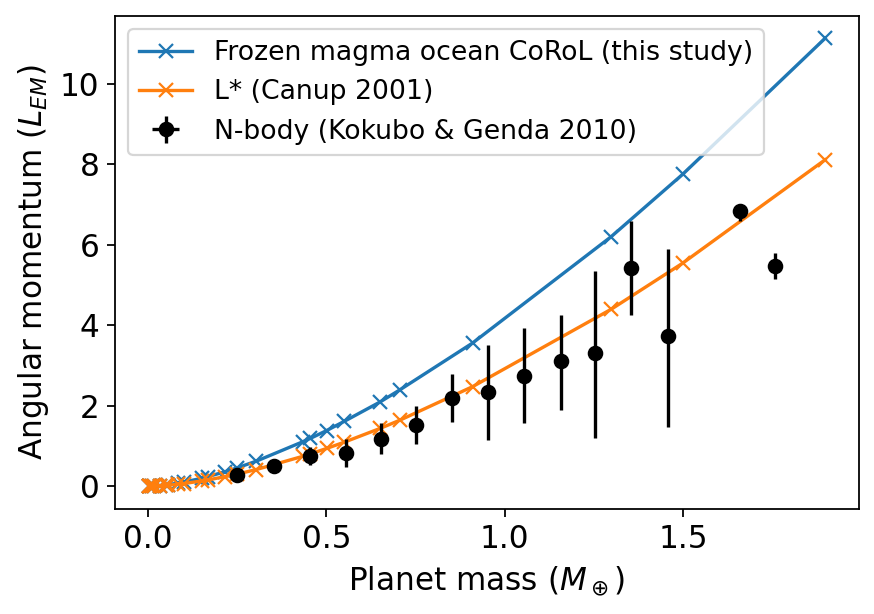

In [28]:
plt.figure(figsize=(6, 4), dpi=80)
plt.plot(Mcorols,Lcorols,label='Frozen magma ocean CoRoL (this study)',marker='x')
plt.plot(Mcorols,Lzstars,label='L* (Canup 2001)',marker='x')
plt.errorbar(KG10_M,KG10_L_mean/LEM,yerr/LEM,xerr/LEM,fmt='o',color='k',label='N-body (Kokubo & Genda 2010)')
plt.legend(fontsize=12)
plt.ylabel('Angular momentum ($L_{EM}$)',size=14)
plt.xlabel('Planet mass ($M_\oplus$)',size=14)
imname='CoRoL_lstar_kokubo'+'.pdf'
plt.savefig(imname,bbox_inches='tight')

## Figure 9

In [29]:
class simdata_abbr(object):
    def __init__(self,Lzbnd,Mbound,Lztot,M_t,M_i,Lzstarstandard,Lzstar,synflag,QS,thetamarker,sizemarker,ratiomarker,outcomemarker,QstarS,label):
        self.Lzbnd=Lzbnd
        self.Mbound=Mbound
        self.Lztot=Lztot
        self.M_t=M_t
        self.M_i=M_i
        self.Lzstarstandard=Lzstarstandard
        self.Lzstar=Lzstar
        self.synflag=synflag
        self.QS=QS
        self.thetamarker=thetamarker
        self.sizemarker=sizemarker
        self.ratiomarker=ratiomarker
        self.outcomemarker=outcomemarker
        self.QstarS=QstarS
        self.label=label

#temp=np.loadtxt('Postema_accretionlistno0.csv',unpack=True,delimiter=',')      
[Lzbnd,Mbound,Lztot,M_t,M_i,Lzstarstandard,Lzstar,synflag,QS,thetamarker,sizemarker,ratiomarker,outcomemarker,QstarS,label,temp]=np.loadtxt('Postema_accretionlistno0.csv',unpack=True,delimiter=',',dtype={'names':('Lzbnd','Mbound','Lztot','M_t','M_i','Lzstarstandard','Lzstar','synflag','QS','thetamarker','sizemarker','ratiomarker','outcomemarker','QstarS','label','nan'),'formats':('float64','float64','float64','float64','float64','float64','float64','float64','float64','<U8','<U8','<U8','<U8','float64','<U8','str')})
#print(sizemarker)
accretionlistno0=[] 
for i in range(np.size(Lzbnd)):
    accretionlistno0=np.append(accretionlistno0,simdata_abbr(Lzbnd[i],Mbound[i],Lztot[i],M_t[i],M_i[i],Lzstarstandard[i],Lzstar[i],synflag[i],QS[i],thetamarker[i],sizemarker[i],ratiomarker[i],outcomemarker[i],QstarS[i],label[i]))

[Lzbnd,Mbound,Lztot,M_t,M_i,Lzstarstandard,Lzstar,synflag,QS,thetamarker,sizemarker,ratiomarker,outcomemarker,QstarS,label,temp]=np.loadtxt('Postema_hitandrunlist.csv',unpack=True,delimiter=',',dtype={'names':('Lzbnd','Mbound','Lztot','M_t','M_i','Lzstarstandard','Lzstar','synflag','QS','thetamarker','sizemarker','ratiomarker','outcomemarker','QstarS','label','nan'),'formats':('float64','float64','float64','float64','float64','float64','float64','float64','float64','<U8','<U8','<U8','<U8','float64','<U8','str')})
#print(sizemarker)
hitandrunlist=[] 
for i in range(np.size(Lzbnd)):
    hitandrunlist=np.append(hitandrunlist,simdata_abbr(Lzbnd[i],Mbound[i],Lztot[i],M_t[i],M_i[i],Lzstarstandard[i],Lzstar[i],synflag[i],QS[i],thetamarker[i],sizemarker[i],ratiomarker[i],outcomemarker[i],QstarS[i],label[i]))

In [30]:
## This is the CoRoL fit function from the manuscript, nothing changes from just interpolating between the observed CoRoL points
def corot(M):
    return np.exp(1.33045+0.221544*np.exp(-M)+1.64827*np.log(M))

In [31]:
## HISTOGRAM
def COROL_hist(simlistlist,ax=None,labels=None,xlim=None,star=False,loglog=False,legend=True,colors=None,Lzstar=False,title=None,savefig=None,corolfn=corot,L0=False,bins=10,combined=False):
    matplotlib.rcParams.update(matplotlib.rcParamsDefault)
    if ax is None: 
        fig,ax=plt.subplots(1,1,figsize=(8,5))
        axset=True
    else: axset=False
    count=0
    allLz=np.array([])
    allLz0=np.array([])
    allLzstar=np.array([])
    #print(simlistlist)
    print(len(simlistlist))
    for i in range(len(simlistlist)):
        simlist = simlistlist[i]
        for j in range(np.size(simlist)):
            sim=simlist[j]  
            allLz=np.append(allLz,sim.Lzbnd/np.amax([corolfn(sim.Mbound)]))
            allLz0=np.append(allLz0,np.amax(sim.Lztot)/np.amax([corolfn(sim.M_t+sim.M_i)]))
            allLzstar=np.append(allLz,sim.Lzbnd/sim.Lzstarstandard)
    if Lzstar==True: histarr=allLzstar
    if L0==True: histarr=allLz0
    else: histarr=allLz
    flabel=None
    if combined:
         flabel='$L_{bnd}$'

    if combined:
        counts2,bins2 = np.histogram(allLz0,bins=bins,density=False,)
        ax.stairs(counts2/np.size(allLz0),bins2,fill=True,label='$L_{0}$')
        
    counts1,bins1 = np.histogram(histarr,bins=bins,density=False)
    print(counts1/np.size(histarr),bins1)
    print('Median:',np.median(histarr))
    ax.stairs(counts1/np.size(histarr),bins1,fill=True,label=flabel)
    if combined:
        ax.stairs(counts2/np.size(allLz0),bins2,fill=False,color='tab:blue')
    if Lzstar: ax.set_xlabel('$L_Z/L_*$',size=16)
    if L0: ax.set_xlabel('$L_{Z,0}/L_{CoRoL}$',size=16)
    else:ax.set_xlabel(r'$L/L_\text{CoRoL}^\text{cond}$',size=16)
    ax.set_ylabel('Population fraction',size=16)
    if combined:
        ax.legend(fontsize=16)
    if title is not None:
        ax.set_title(title,size=16)
    if axset:
        if savefig is not None:
            imname=savefig+'.pdf'
            plt.savefig(imname,bbox_inches='tight')
        plt.show()

1
[0.         0.         0.02608696 0.02608696 0.13043478 0.12173913
 0.13043478 0.06956522 0.10434783 0.11304348 0.03478261 0.07826087
 0.06956522 0.04347826 0.05217391 0.         0.         0.
 0.         0.         0.         0.         0.         0.        ] [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2 ]
Median: 0.396644812154222


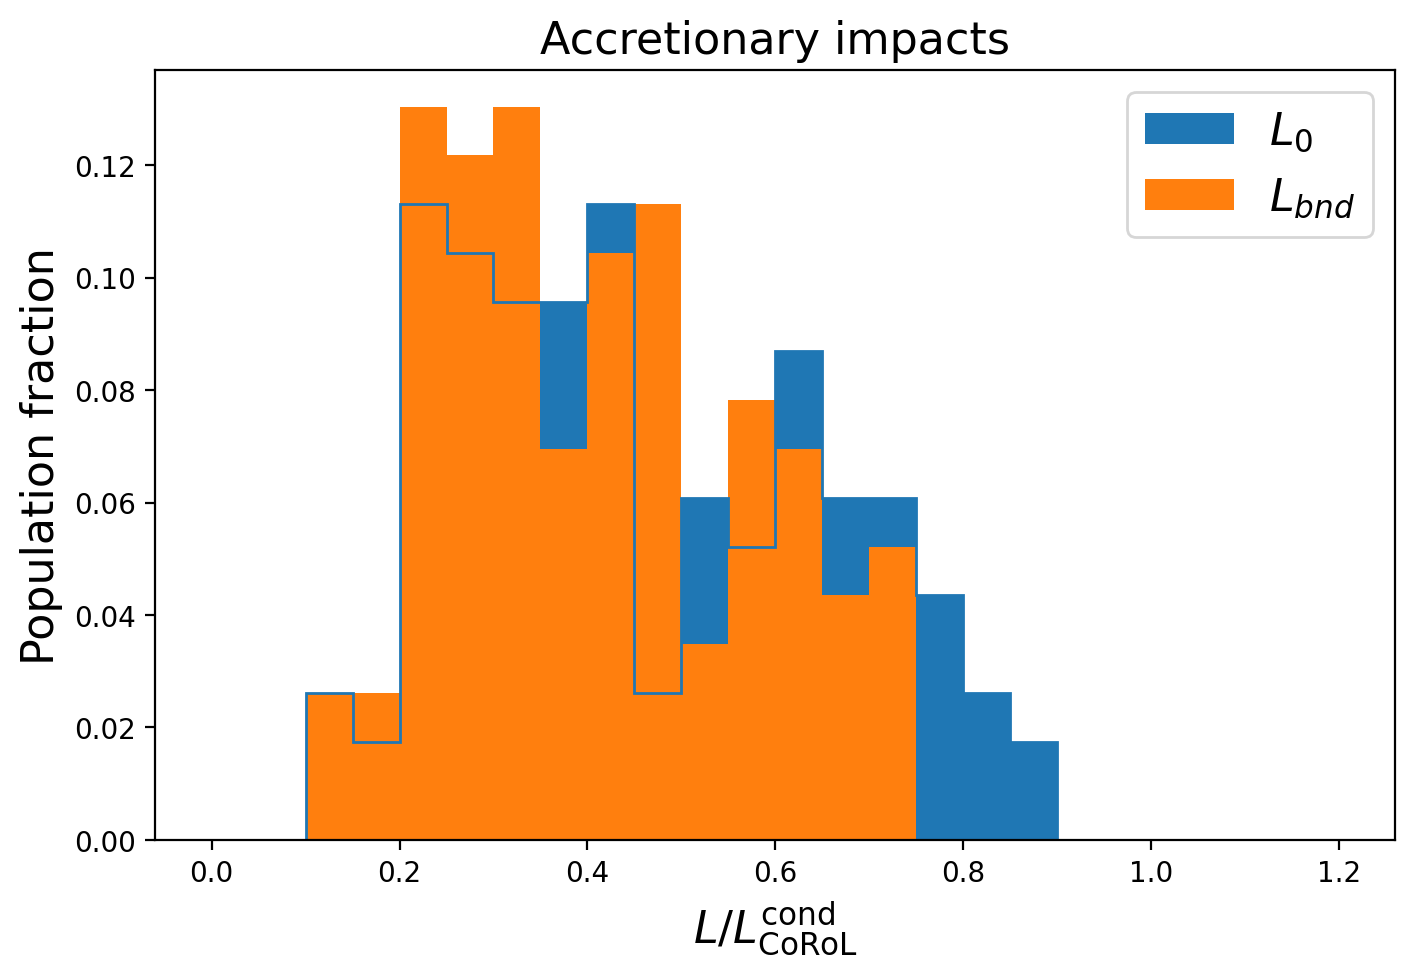

1
[0.00862069 0.04310345 0.21551724 0.04310345 0.01724138 0.0862069
 0.11206897 0.06034483 0.05172414 0.05172414 0.09482759 0.06034483
 0.04310345 0.01724138 0.02586207 0.00862069 0.02586207 0.00862069
 0.00862069 0.01724138 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.        ] [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35
 1.4  1.45 1.5  1.55 1.6  1.65 1.7 ]
Median: 0.3362965003946372


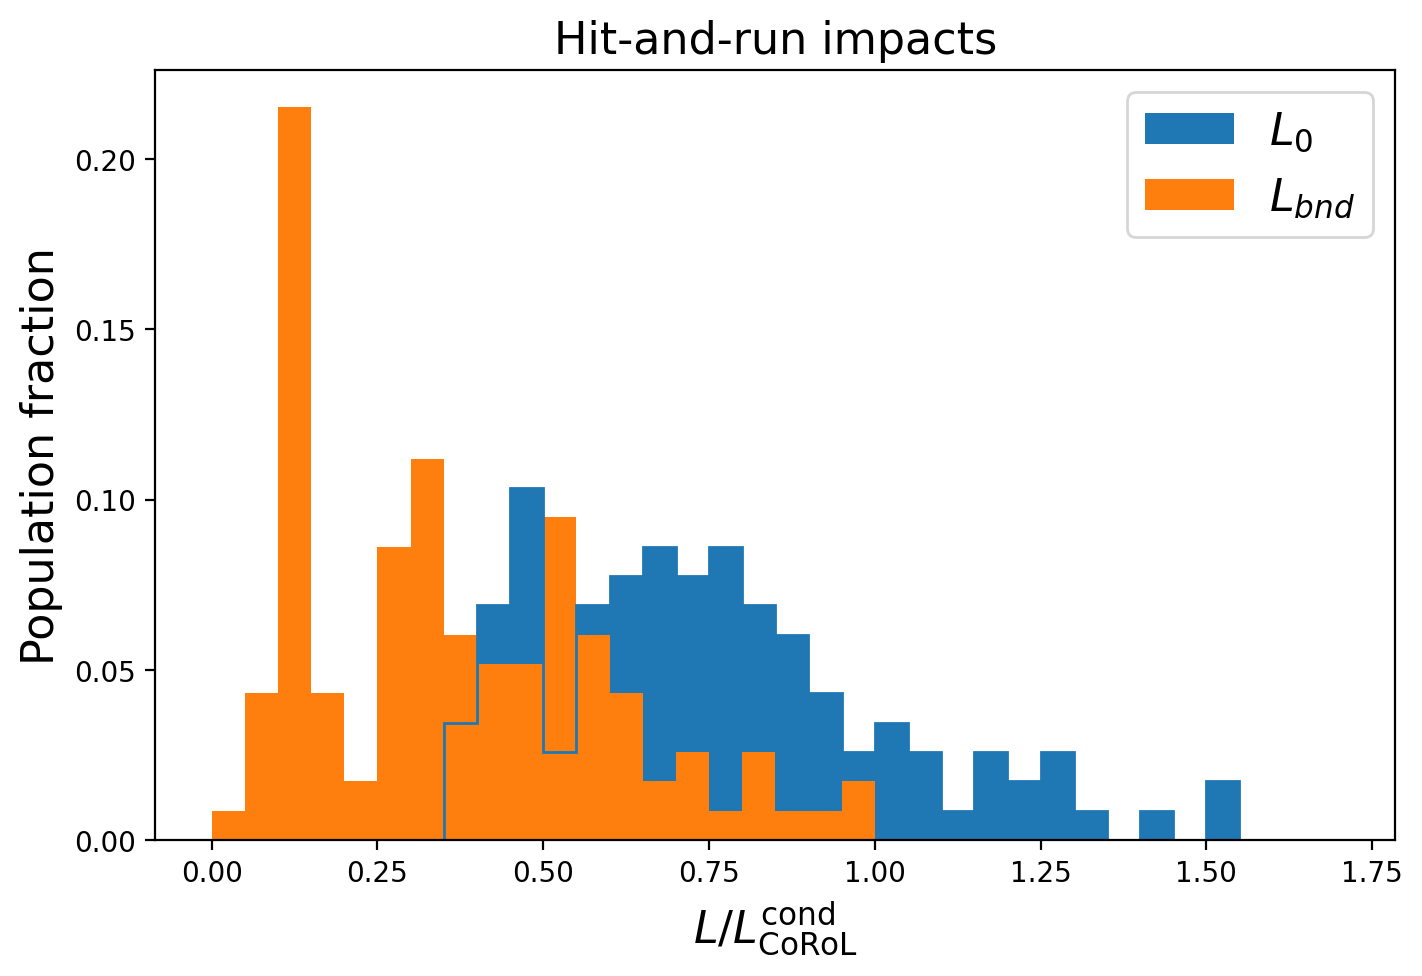

In [32]:
COROL_hist([accretionlistno0],bins=np.arange(0,1.25,.05),title='Accretionary impacts',savefig='accretion_hist',combined=True)
COROL_hist([hitandrunlist],bins=np.arange(0,1.75,.05),title='Hit-and-run impacts',savefig='hnr_hist_all',combined=True)


## Figure 10

In [33]:
def bigfit_ML(M,L):
    c00=153.53959723963789
    c01=0.6633160603278092
    c02=-0.9592188598031302
    c10=243.19051119279166
    c11=-3.366759602220585
    c12=-22.041247448477787
    c20=-18.332505614890877
    c21=-2.6533013645110426
    c22=-1.6783109326520955
    c30=2.780157903976064
    c31=-4.267852305563586
    c32=-1.874789905348047
    # need M in M_earth and L in L_EM
    return c00*M**c01*np.exp(c02*np.exp(-M))+c10*M**c11*np.exp(c12*np.exp(-M))*L+c20*M**c21*np.exp(c22*np.exp(-M))*L**2+c30*M**c31*np.exp(c32*np.exp(-M))*L**3

In [34]:
from matplotlib.colors import Normalize

def CoRoL_LM(simlistlist,ax=None,labels=None,xlim=None,star=False,loglog=False,markers=None,legend=True,colors=None,Lzstar=False,title=None,savefig=None):
    matplotlib.rcParams.update(matplotlib.rcParamsDefault)
    if ax is None: 
        fig,ax=plt.subplots(1,1,figsize=(14,8))
        axset=True
    else: axset=False
    count=0
    allQS=np.array([])
    allLz=np.array([])
    allP=np.array([])
    allLcorols=np.array([])
    for i in range(np.shape(simlistlist)[0]):
        simlist = simlistlist[i]
        Lzs=np.zeros(np.size(simlist))
        QSs=np.zeros(np.size(simlist))
        Ps=np.zeros(np.size(simlist))
        for j in range(np.size(simlist)):
            sim=simlist[j]
            if Lzstar: Lzs[j]=sim.Lzbnd/sim.Lzstar
            else: 
                Lzs[j]=sim.Lzbnd
            QSs[j] = sim.QS
            allLz=np.append(allLz,Lzs[j])
            allQS=np.append(allQS,QSs[j])
            Ps[j]=bigfit_ML(sim.Mbound,sim.Lzbnd)
            allP=np.append(allP,Ps[j])
            allLcorols=np.append(allLcorols,Lzs[j]/corot(sim.Mbound))
    if colors=='Lz': 
        if Lzstar: pltnorm=Normalize(vmin=np.amin(allLz),vmax=np.amax(allLz))
        else: pltnorm=LogNorm(vmin=np.amin(allLz),vmax=1,clip=True)
    if colors=='LCoRoL':
        pltnorm=Normalize(vmin=0,vmax=1)
    if colors=='QS': pltnorm=LogNorm(vmin=np.amin(allQS),vmax=np.amax(allQS))
    if colors=='P': pltnorm=Normalize(vmin=0,vmax=1)

    lspace=np.linspace(1e-4,2)
    L0space=bigfit_ML(lspace,np.zeros(np.size(lspace)))
    corolspace=bigfit_ML(lspace,corot(lspace))

    ax.fill_between(lspace,0.7*L0space,0.8*L0space,color="lightgrey",label='Empirical equilibration P',alpha=.5)
    
    synmarkers=["o","*","*"]
    synlabel=['Post-impact: Planet + Disk','Synestia','Co-CoRoL']

    sclist=np.zeros(3)
    for i in range(np.shape(simlistlist)[0]):
        simlist = simlistlist[i]
        QSs=np.zeros(np.size(simlist))
        Lzs=np.zeros(np.size(simlist))
        Ps=np.zeros(np.size(simlist))
        Ms=np.zeros(np.size(simlist))
        for j in range(np.size(simlist)):
            sim=simlist[j]
            if markers=='theta':marker=sim.thetamarker
            elif markers=='size':marker=sim.sizemarker
            elif markers=='ratio':marker=sim.ratiomarker
            elif markers=='outcome':marker=sim.outcomemarker
            elif markers=='synestia':marker=synmarkers[int(sim.synflag)]
            if markers is None:marker=markerlist[(count//10)%np.size(markerlist)]
            if Lzstar: Lzs[j]=sim.Lzbnd/sim.Lzstar
            else: Lzs[j]=sim.Lzbnd
            if star:
                QSs[j] = sim.QstarS
                #logallQS=np.append(logallQS,np.log10(sim.QstarS))
            else:
                QSs[j] = sim.QS
                #logallQS=np.append(logallQS,np.log10(sim.QS))
            Ms[j]=sim.Mbound
            Ps[j]=bigfit_ML(sim.Mbound,sim.Lzbnd)
            if labels is None:
                if colors is not None:
                    if colors=='Lz':c=Lzs[j]
                    if colors=='QS':c=QSs[j]
                    if colors=='P':c=Ps[j]
                    if colors=='LCoRoL':c=Lzs[j]/corot(sim.Mbound)
                    if sclist[int(sim.synflag)]==0:
                        if sim.synflag!=2: ax.scatter(Ms[j],Ps[j],label=synlabel[int(sim.synflag)],s=65,marker=marker,c=(0.5+0.1*sim.synflag),norm=pltnorm,cmap='viridis')
                        sclist[int(sim.synflag)]+=1
                    ax.scatter(Ms[j],Ps[j],label=None,s=65,marker=marker,c=c,norm=pltnorm,cmap='viridis')
                else:
                    ax.scatter(Ms[j],Ps[j],label=None,s=65,marker=marker)
                count+=1
        if labels is not None:
            #if logfit:
            ax.scatter(Ms,Ps,label=labels[i],s=65,marker=marker)

    ax.plot(lspace,L0space,color='k',label=r'Non-rotating P$_{\rm CMB}$')
    ax.plot(lspace,corolspace,color='red',ls='--',label=r'P$_{\rm CMB}$ @ L$^{\rm cond}_{\rm CoRoL}$')
    
    if colors is not None:
        cbar=plt.colorbar(cm.ScalarMappable(norm=pltnorm, cmap='viridis'), ax=ax)
        #cbar=plt.colorbar(cm.ScalarMappable(cmap='viridis'), ax=ax)
        cbar.ax.tick_params(which='major', labelsize=17)
        if colors=='Lz':
            if Lzstar:cbar.set_label('LzBound/L*',size=18)#,size=22
            else:cbar.set_label(r'Planet $L_Z$',size=18)#,size=22
        if colors=='QS':cbar.set_label('$Q_S$ [J/kg]',size=18)#,size=22
        if colors=='P':cbar.set_label(r'$P_{\rm CMB}/P_{\rm CMB,CoRoL}$',size=18)
        if colors=='LCoRoL':cbar.set_label(r'$L/L^{\rm cond}_{\rm CoRoL}$',size=20)
    ax.tick_params(axis='both', which='major', labelsize=17)
    ax.tick_params(axis='both', which='minor', labelsize=17)
    ax.set_xlabel(r'Largest Remnant Mass (M$_{\oplus}$)',size=20)#,size=24
    ax.set_ylabel(r'Condensed, Rotating CMB Pressure (GPa)',size=20)#,size=24
    #if legend: ax.legend(bbox_to_anchor=(1.3, 1.0), loc='upper left')#,fontsize=14
    if legend: ax.legend(loc='upper left',fontsize=18)#,fontsize=14
    if loglog:
        ax.set_yscale('log')
    #ax.set_xlim(0,None)
    ax.set_xscale('linear')
    ax.set_yscale('linear')
    if title is not None:
        ax.set_title(title,size=16)
    if axset:
        if savefig is not None:
            imname=savefig+'.pdf'
            plt.savefig(imname,bbox_inches='tight')
        plt.show()

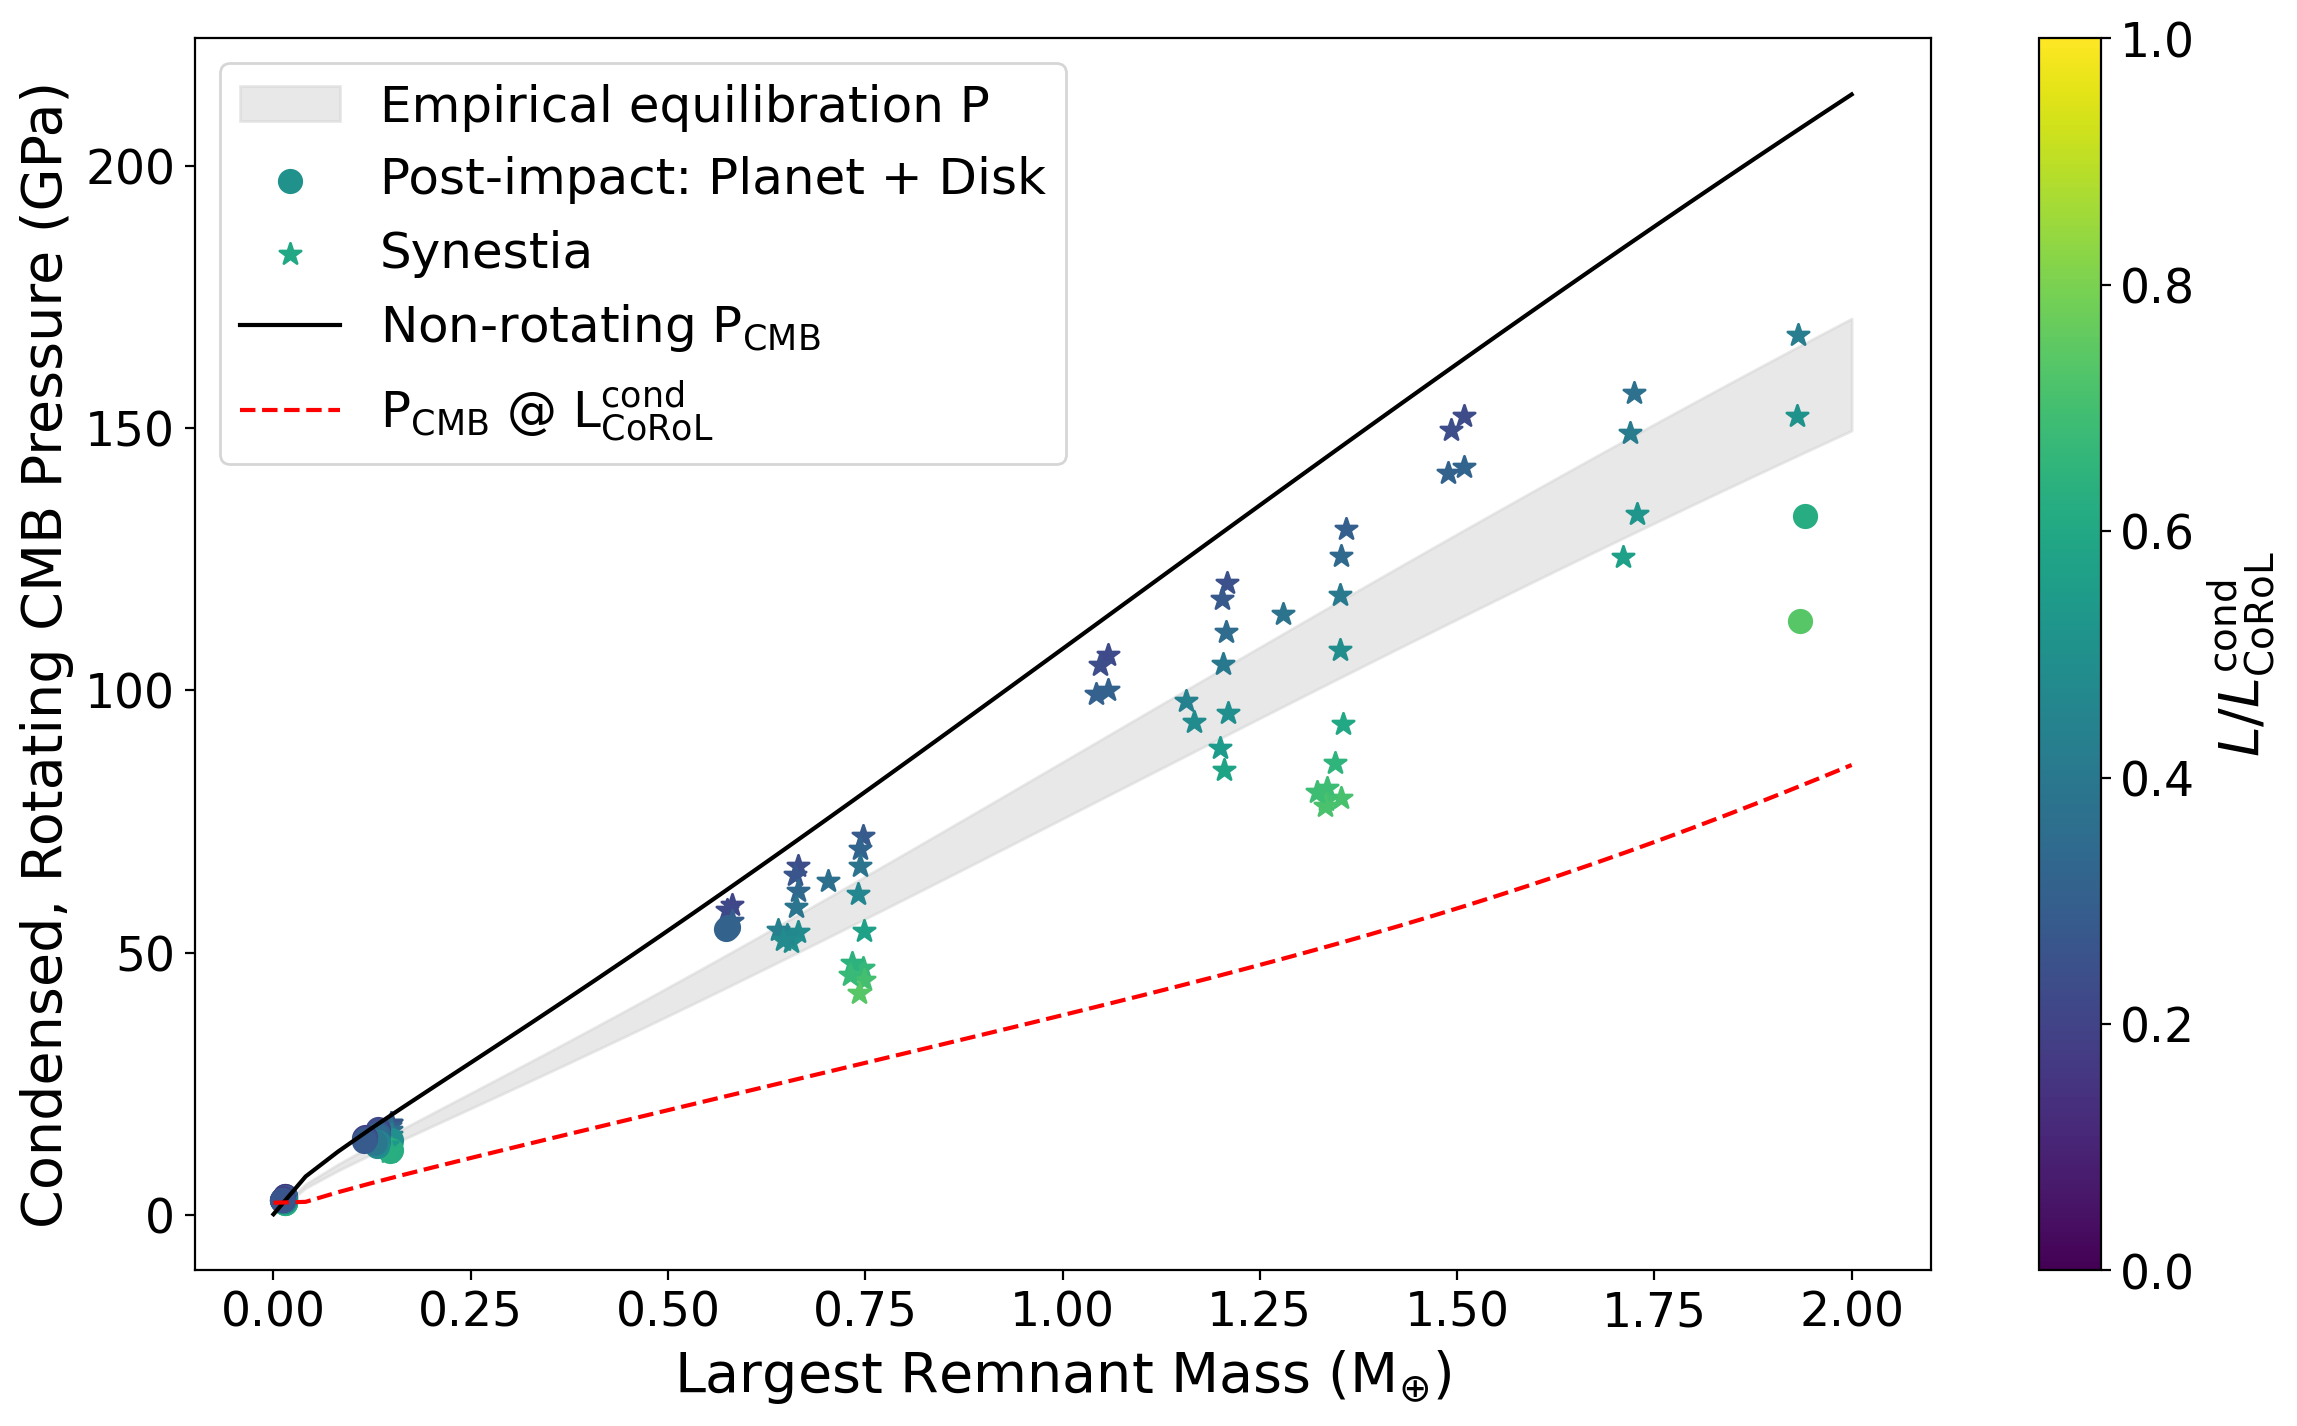

In [35]:
CoRoL_LM([accretionlistno0],labels=None,loglog=False,colors='LCoRoL',legend=True,markers='synestia',title=None,savefig='postema_CoRoL_diagram')

## Figure 11

Quintana+16 (a): N=916, synestia 318 (35%), M_lr 0.144-1.801, median P/P0=0.719
Clement+19 (b): N=532, synestia 62 (12%), M_lr 0.056-1.900, median P/P0=0.786
Clement+23 (c): N=149, synestia 23 (15%), M_lr 0.056-1.537, median P/P0=0.756
wrote fig_nbody_collisions.png / .pdf


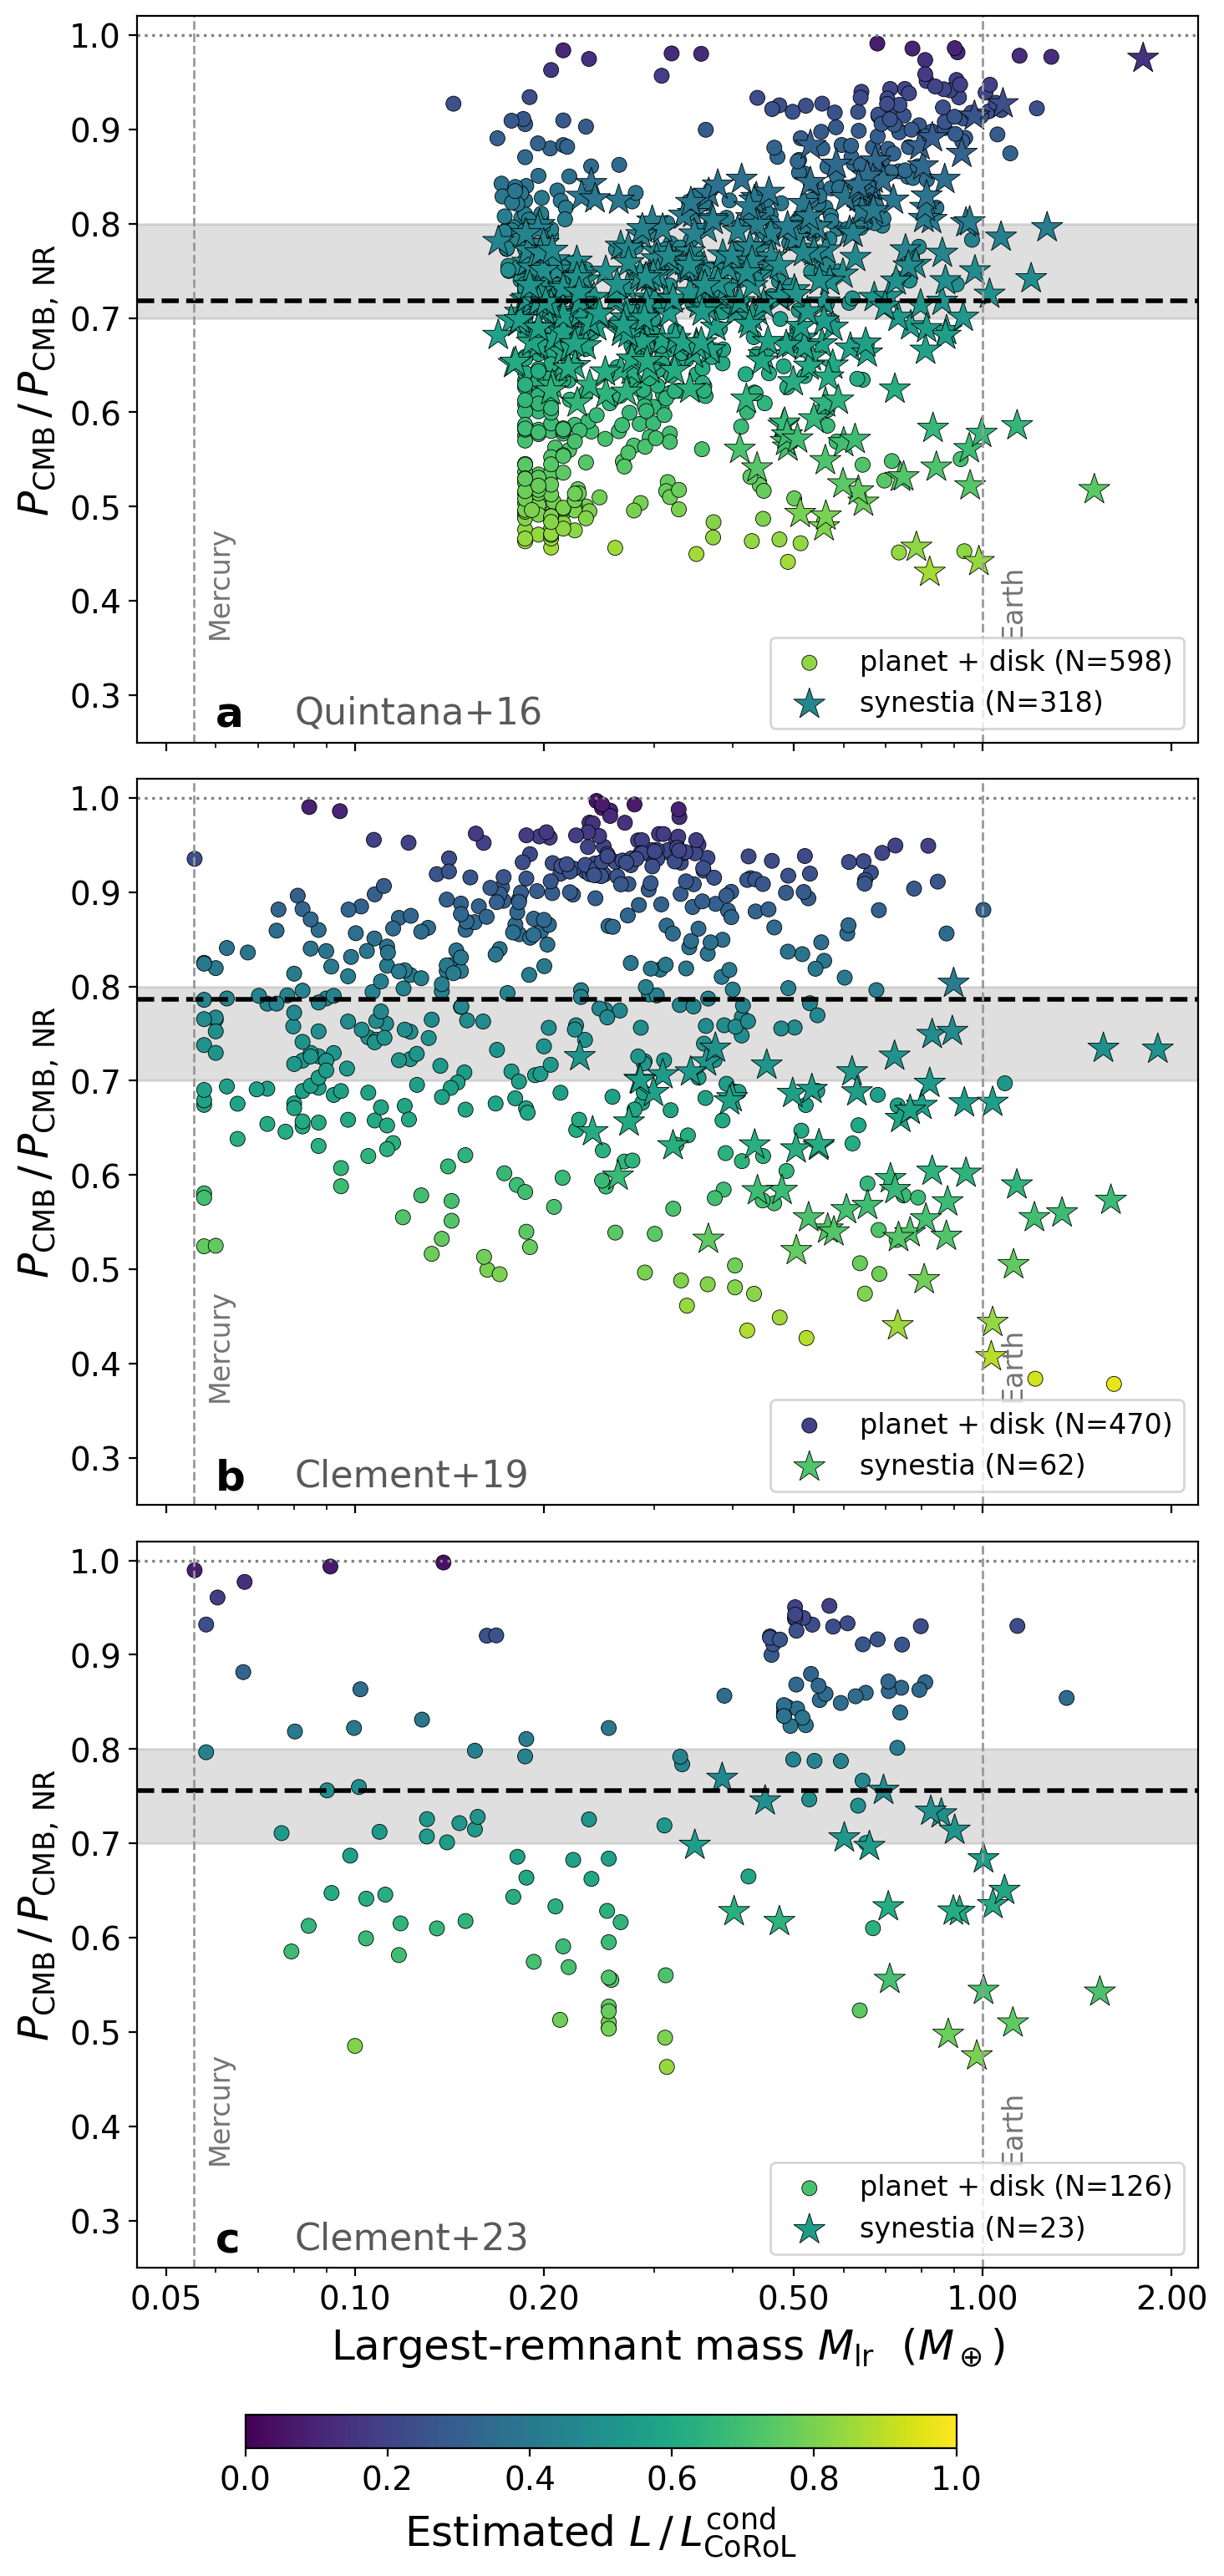

In [36]:
### FIG:NBODY COLLISIONS
import glob
import pandas as pd

from corotation_limit import L_corot
from Jbound_scaling_law import J_bound_nonrotating_broad
from qs_lock import QS_modified

ME, LEM, JEM = 5.972e24, 3.5e34, 3.61e34
M_MERC = 0.0553                      # Mercury mass [M_earth]
ACC = ['Merge', 'Perfect', 'Graze+Merge']
A_SYN, pQS, pM = np.load('_joint_coef.npy')   # [A, pQS, pM] = 1.42, -0.40, 1.19

# --- Postema+25 Eq 7 / Table 4 : P_CMB(M,L) (robust to low mass) --------------
C_TAB4 = np.array([[153.528, 0.663378, -0.959155], [63.3206, -2.22476, -18.474],
                   [-17.742, -2.63846, -1.60827], [2.61647, -4.23984, -1.74688]])
def _gi(i, M): c = C_TAB4[i]; return c[0]*M**c[1]*np.exp(c[2]*np.exp(-M))
def P_ratio(M, L): return sum(_gi(i, M)*L**i for i in range(4)) / _gi(0, M)

def derive(M, Mt, Mp, Rt, Rp, vimp, b, gamma, vve):
    """(P_CMB/P_norot, L/L_CoRoL, synestia_flag)."""
    Lcor = L_corot(M, type=4)*JEM/LEM                       # condensed Type-4 CoRoL
    mu   = Mt*Mp/(Mt+Mp)
    Limp = mu*vimp*b*(Rt+Rp)
    eta  = J_bound_nonrotating_broad(gamma, vve, b, 1.0)    # scale-free retention law
    Jb   = np.nan_to_num(eta)*Limp/LEM                      # bound AM estimate [L_EM]
    Lret = np.minimum(Jb, Lcor)
    QS   = QS_modified(Mt, Mp, vimp, b, Rt, Rp) / 1e6       # MJ/kg
    syn  = Jb > A_SYN * M**pM * QS**pQS                     # empirical synestia criterion
    return P_ratio(M, Lret), Lret/Lcor, syn

# --- Clement raw loaders (re-extract with the low M_lr floor) -----------------
def load_clement(root, embprefix):
    frames = []
    for f in sorted(glob.glob(os.path.join(root, '*', 'collisions.txt'))):
        frames.append(pd.read_csv(f))
    d = pd.concat(frames, ignore_index=True)
    emb = lambda s: s.str[0].isin(list(embprefix))
    a = d[emb(d.target) & emb(d.projectile) & d.Regime.isin(ACC)].copy()
    a['Mlr'] = a.Mt_Mearth + a.Mp_Mearth - a['m_frag_Mearth']
    a['xi']  = (a.Mlr - a.Mt_Mearth) / a.Mp_Mearth
    a['gam'] = a.Mp_Mearth / a.Mt_Mearth
    return a[(a.Mlr > M_MERC) & (a.xi >= 0.8) & (a.gam > 0.1)].copy()

def derive_clement(c):
    return derive(c.Mlr.values, c.Mt_Mearth.values*ME, c.Mp_Mearth.values*ME,
                  c.Rt_km.values*1e3, c.Rp_km.values*1e3, c['vimp_km/s'].values*1e3,
                  c.b.values, c.gam.values, c['vimp/vesc'].values)

# --- assemble the three datasets ---------------------------------------------
q = pd.read_csv('quintana_collisions.csv')
q = q[(q.Mlr_ME > M_MERC) & (q.xi >= 0.8) & (q.gamma > 0.1)]
qPr, qLo, qS = derive(q.Mlr_ME.values, q.Mt.values, q.Mp.values, q.Rt.values, q.Rp.values,
                      q.Vimp.values, q.b.values, q.gamma.values, q.vve.values)

c1 = load_clement('clement/sims_for_sarah', 'E')
c1Pr, c1Lo, c1S = derive_clement(c1)
c2 = load_clement('clement/sims_for_sarah2_c23', 'EM')
c2Pr, c2Lo, c2S = derive_clement(c2)

panels = [('a', 'Quintana+16', q.Mlr_ME.values, qPr, qLo, qS),
          ('b', 'Clement+19', c1.Mlr.values, c1Pr, c1Lo, c1S),
          ('c', 'Clement+23', c2.Mlr.values, c2Pr, c2Lo, c2S)]

# font sizes
fs1=18 # main labels
fs2=16 # on plot
fs3=12 # small
# ================================ plot ======================================
LBL = dict(fontsize=fs1, color='k')
fig, axs = plt.subplots(3, 1, figsize=(7.6, 15.4), sharex=True)
common = dict(cmap='viridis', vmin=0, vmax=1, edgecolors='k', lw=0.3)
for ax, (lab, name, M, Pr, Lo, S) in zip(axs, panels):
    ax.fill_between([0,3],[.7,.7],[.8,.8],color='grey',alpha=0.25)
    sc = ax.scatter(M[~S], Pr[~S], c=Lo[~S], s=42, marker='o',
                    label=f'planet + disk (N={int((~S).sum())})', **common)
    ax.scatter(M[S], Pr[S], c=Lo[S], s=200, marker='*',
               label=f'synestia (N={int(S.sum())})', **common)
    ax.axhline(np.median(Pr),color='k',ls='--',lw=2)
    ax.axhline(1.0, color='0.5', ls=':', lw=1.2)
    ax.axvline(M_MERC, color='0.6', ls='--', lw=1.0)
    ax.axvline(1.0, color='0.6', ls='--', lw=1.0)
    ax.text(0.058, 0.36, 'Mercury', fontsize=fs3, color='0.45', rotation=90, va='bottom')
    ax.text(1.06, 0.36, 'Earth', fontsize=fs3, color='0.45', rotation=90, va='bottom')
    ax.text(0.06, 0.3, lab, fontsize=fs1, fontweight='bold', va='top') #abc
    ax.text(0.08, 0.3, name, fontsize=fs2, color='0.35', va='top') # study
    ax.set_ylabel(r'$P_{\rm CMB}\,/\,P_{\rm CMB,\,NR}$', **LBL)
    ax.set_ylim(0.25, 1.02); ax.set_xlim(0.045, 2.2); ax.set_xscale('log')
    ax.set_xticks([0.05, 0.1, 0.2, 0.5, 1.0, 2.0])
    ax.get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
    ax.tick_params(labelsize=14)
    ax.legend(fontsize=fs3, loc='lower right')
axs[-1].set_xlabel(r'Largest-remnant mass $M_{\rm lr}$  $(M_\oplus)$', **LBL)

fig.subplots_adjust(left=0.135, right=0.97, top=0.99, bottom=0.115, hspace=0.05)
cax = fig.add_axes([0.22, 0.045, 0.56, 0.013])
cb = fig.colorbar(sc, cax=cax, orientation='horizontal')
cb.set_label(r'Estimated $L\,/\,L_{\rm CoRoL}^{\rm cond}$', **LBL)
cb.ax.tick_params(labelsize=14)
fig.savefig('fig_nbody_collisions', dpi=140)
fig.savefig('fig_nbody_collisions.pdf')
for lab, name, M, Pr, Lo, S in panels:
    print(f'{name} ({lab}): N={len(M)}, synestia {int(S.sum())} ({100*S.mean():.0f}%), '
          f'M_lr {M.min():.3f}-{M.max():.3f}, median P/P0={np.median(Pr):.3f}')
print('wrote fig_nbody_collisions.png / .pdf')
plt.show()

## *See Mathematica Notebook for Appendix Figures 12 & 13* 

## Appendix Figure 14

wrote fig_bound_am.png   (N=486, RMS(eta)=0.103)


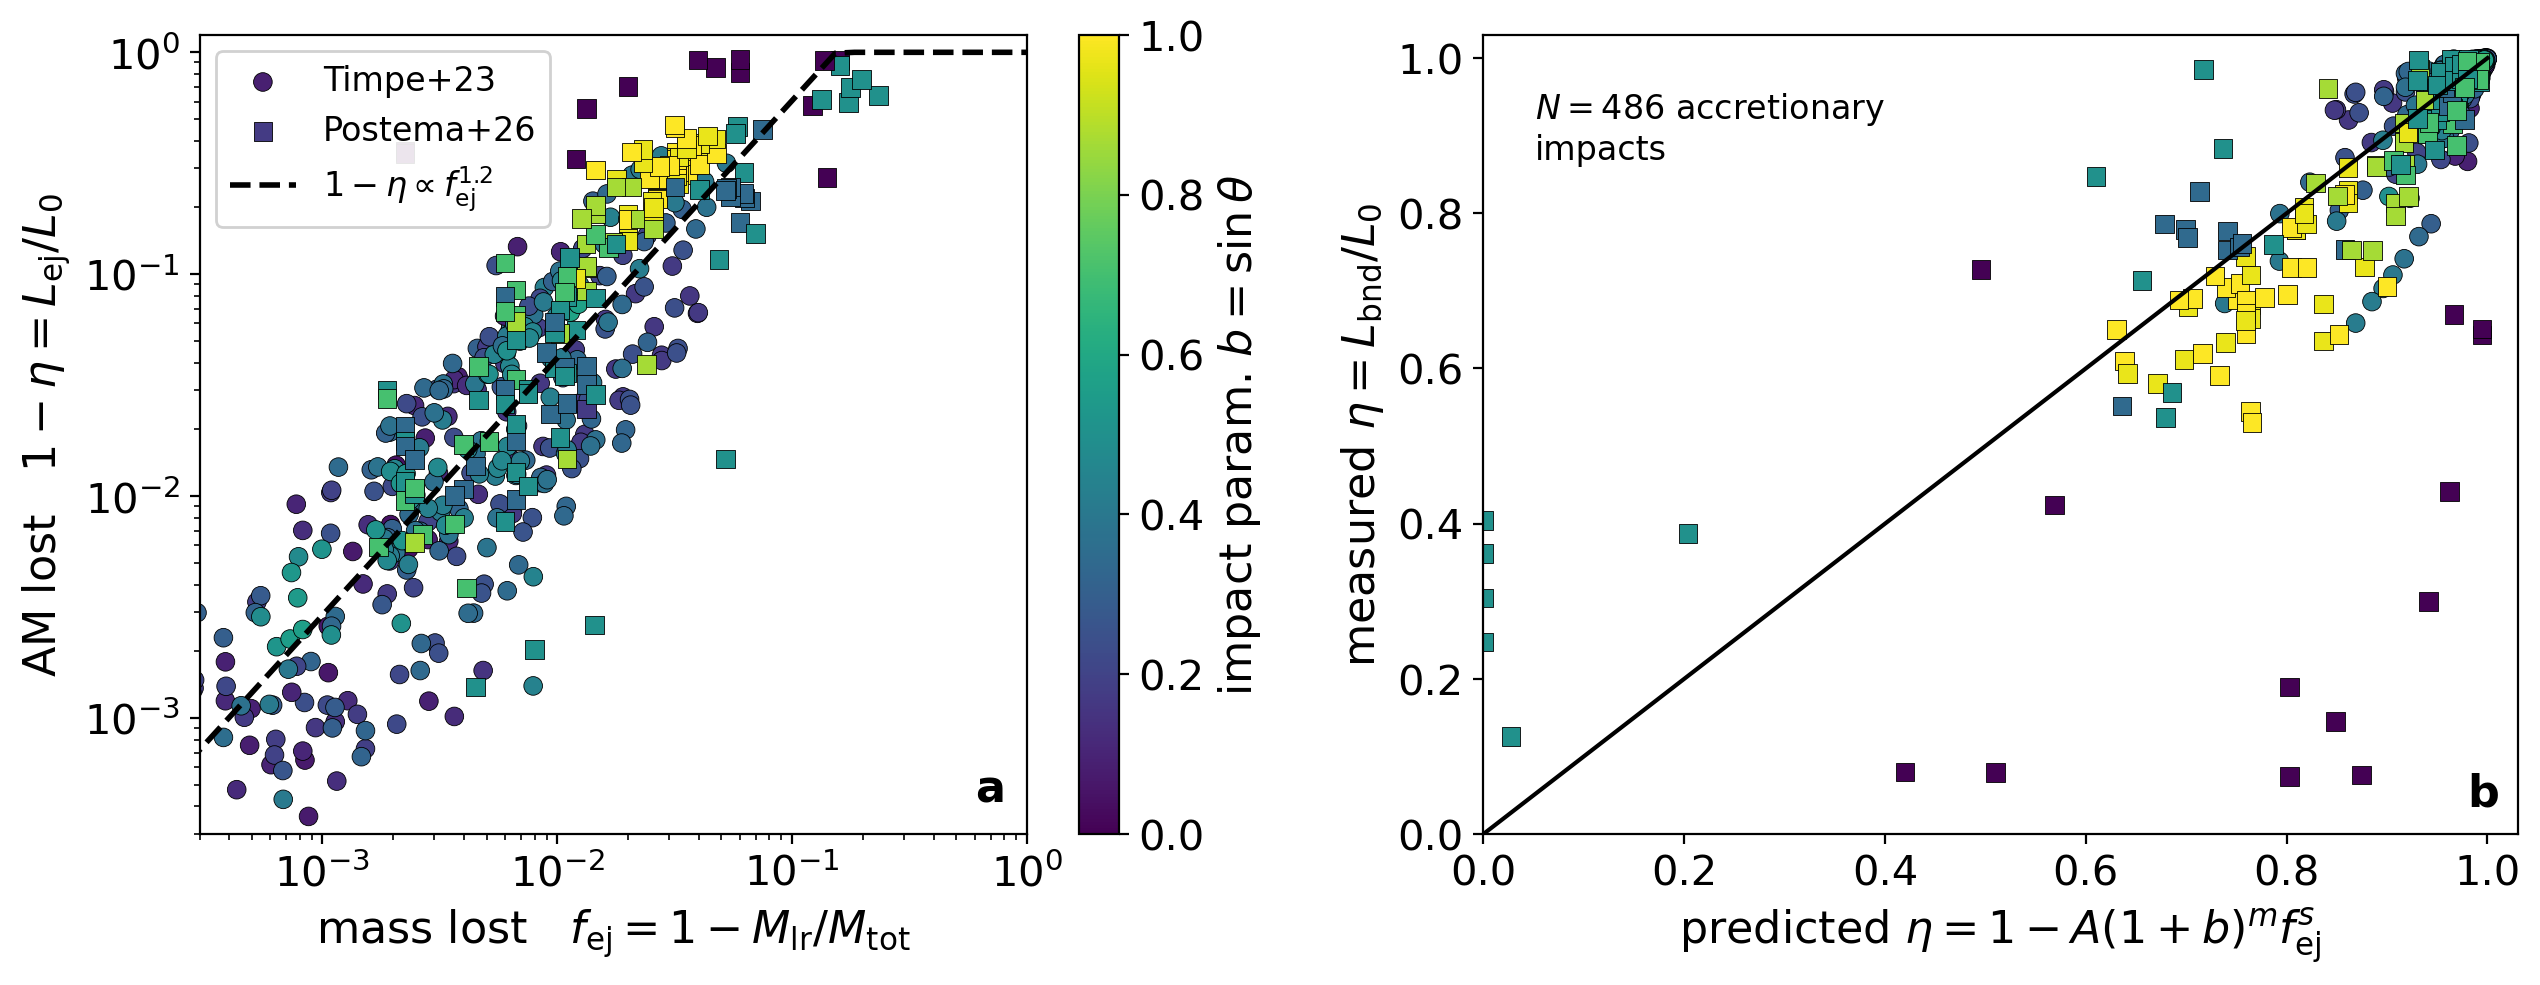

In [37]:
### FIG:BOUND AM

from explore_ejecta_AM import assemble

A, m, s = 4.362941299820175, 1.274173427265838, 1.101167386820984   # eta = 1 - A(1+b)^m f_ej^s

d   = assemble()
acc = d[(d.xi > 0.2) & (d.f_ej > 1e-4) & ((1 - d.eta) > 1e-4)].copy()   # accretionary incl. graze-merge
acc['eta_pred'] = np.clip(1 - A*(1+acc.b)**m * acc.f_ej**s, 0, 1)
rms = np.sqrt(((acc.eta - acc.eta_pred)**2).mean())

plt.rcParams.update({'font.size': 15, 'axes.labelsize': 16, 'axes.titlesize': 17})
fig, ax = plt.subplots(1, 2, figsize=(13, 5.2))
cmap = plt.cm.viridis

# ---- (A) AM lost vs mass lost
for src, mk, lab in [('TimpeMeier', 'o', 'Timpe+23'), ('Postema', 's', 'Postema+26')]:
    g = acc[acc.src == src]
    sc = ax[0].scatter(g.f_ej, 1 - g.eta, c=g.b, cmap=cmap, vmin=0, vmax=1,
                       marker=mk, s=45, edgecolor='k', linewidth=0.3, label=lab)
xx = np.logspace(-4, 0, 50)
ax[0].plot(xx, np.clip(8.77*xx**1.16, 0, 1), 'k--', lw=2, label=r'$1-\eta\propto f_{\rm ej}^{1.2}$')
ax[0].set(xscale='log', yscale='log', xlim=(3e-4, 1), ylim=(3e-4, 1.2),
          xlabel=r'mass lost   $f_{\rm ej}=1-M_{\rm lr}/M_{\rm tot}$',
          ylabel=r'AM lost   $1-\eta=L_{\rm ej}/L_0$')
#ax[0].set_title('AM lost tracks mass lost', fontweight='bold')
ax[0].legend(fontsize=12, loc='upper left', framealpha=0.9)
ax[0].text(.6,6.e-4,'a',fontsize=16,fontweight='bold',va='top') #ab
cb = fig.colorbar(sc, ax=ax[0]); cb.set_label(r'impact param. $b=\sin\theta$')

# ---- (B) predicted vs measured eta
for src, mk in [('TimpeMeier', 'o'), ('Postema', 's')]:
    g = acc[acc.src == src]
    ax[1].scatter(g.eta_pred, g.eta, c=g.b, cmap=cmap, vmin=0, vmax=1,
                  marker=mk, s=45, edgecolor='k', linewidth=0.3)
ax[1].plot([0, 1], [0, 1], 'k-', lw=1.5)
ax[1].set(xlim=(0, 1.03), ylim=(0, 1.03),
          xlabel=r'predicted $\eta = 1-A(1+b)^m f_{\rm ej}^{s}$',
          ylabel=r'measured $\eta = L_{\rm bnd}/L_0$')
#ax[1].set_title(f'retention law   (RMS $={rms:.2f}$)', fontweight='bold')
ax[1].text(0.05, 0.93, f'$N={len(acc)}$ accretionary\nimpacts',
           transform=ax[1].transAxes, fontsize=12, va='top')
ax[1].text(.98,.08,'b',fontsize=16,fontweight='bold',va='top') #ab

fig.tight_layout()
fig.savefig('fig_bound_am.png', dpi=150, bbox_inches='tight')
fig.savefig('fig_bound_am.pdf')
print(f'wrote fig_bound_am.png   (N={len(acc)}, RMS(eta)={rms:.3f})')
plt.show()

## Appendix Figure 15

wrote fig_synestia_criteria.pdf / .png   (J_crit = 1.42 M^1.19 QS^-0.40)


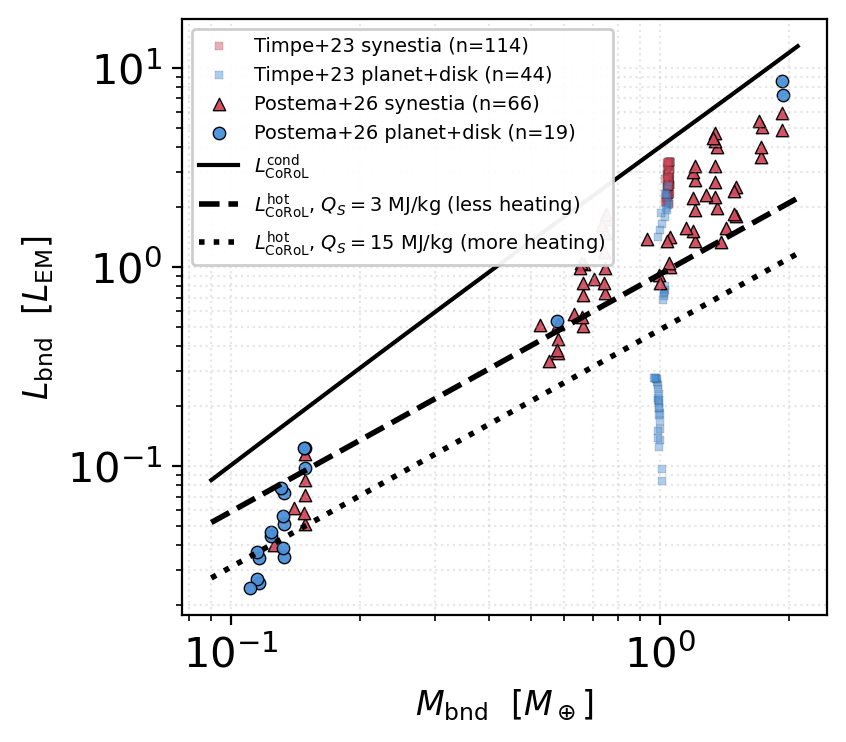

In [38]:
### FIG:SYNESTIA_CRITERIA
import os
from corotation_limit import L_corot, L_canup
J_EM = 3.61e34

HERE = (os.getcwd())   # run from anywhere; data sits beside script
#HERE = os.path.dirname(os.path.abspath(os.getcwd()))   # run from anywhere; data sits beside script
D = pd.read_csv(f"{HERE}/joint_synestia_data.csv")
A, pQS, pM = np.load(f"{HERE}/_joint_coef.npy")

P = D[D.src == 'Postema']; T = D[D.src == 'TM']
fig, ax = plt.subplots(figsize=(4.5, 4))

# TM (non-rotating, grazing) small dots by HSSL label
for lab, sub, c in [('Timpe+23 synestia', T[T.syn==1], '#d1495b'),
                    ('Timpe+23 planet+disk',                 T[T.syn==0], '#4a90d9')]:
    ax.scatter(sub.M, sub.J, s=10, marker='s', facecolor=c, alpha=0.45, edgecolor='k', linewidth=0.1, label=f'{lab} (n={len(sub)})')

# Postema markers by label
for lab, sub, mk, c in [('Postema+26 synestia', P[P.syn==1], '^', '#d1495b'),
                        ('Postema+26 planet+disk',       P[P.syn==0], 'o', '#4a90d9')]:
    ax.scatter(sub.M, sub.J, s=20, marker=mk, facecolor=c, edgecolor='k',
               linewidth=0.5, alpha=0.95, label=f'{lab} (n={len(sub)})')

MM = np.logspace(np.log10(0.09), np.log10(2.1), 100)
LL = L_corot(MM, type=4)
ttt = r'$L_{\rm CoRoL}^{\rm hot}$'
ax.plot(MM,LL,'k-',label=r'$L_{\rm CoRoL}^{\rm cond}$')
for QS, ls, lab in [(3.0, '--', r'$Q_S=3$ MJ/kg (less heating)'),
                    (15.0, ':',  r'$Q_S=15$ MJ/kg (more heating)')]:
    ax.plot(MM, A * MM**pM * QS**pQS, color='k', ls=ls, lw=2,
            label=f'{ttt}, {lab}')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$M_{\rm bnd}$  [$M_\oplus$]', fontsize=12)
ax.set_ylabel(r'$L_{\rm bnd}$  [$L_{\rm EM}$]', fontsize=12)
#ax.set_title('Joint synestia criterion (non-rotating TM + Postema)\n'
#             r'$J_{\rm bound} > %.2f\,M^{%.2f}\,Q_S^{%.2f}$   (AM $\uparrow$ mass, $\downarrow$ heating)'
#             % (A, pM, pQS), fontsize=11)
ax.legend(fontsize=7, loc='upper left', framealpha=0.95)
ax.grid(True, which='both', ls=':', alpha=0.3)
fig.tight_layout()
fig.savefig(f"{HERE}/fig_synestia_criteria.pdf", bbox_inches='tight')
fig.savefig(f"{HERE}/fig_synestia_criteria.png", dpi=150, bbox_inches='tight')
print(f"wrote fig_synestia_criteria.pdf / .png   (J_crit = {A:.2f} M^{pM:.2f} QS^{pQS:.2f})")
plt.show()